# Indicadores econoómicos

# Descripción

Este proyecto tiene como objetivos reducir la información de 11 atributos económicos y sociales en unas nuevas variables que engloben todos los indicadores y tratar de agrupar a los países en clusters lo más definidos posibles para tener una mejor estructura económica y social del mundo.

Para esta actividad se consideran los siguientes predictores:

| Variable | Descripción |
|----------|-------------|
| Tasa | Tasa anual de crecimiento de la población. |
| Mortalidad | Tasa de mortalidad infantil por cada 1000 nacidos vivos. |
| Mujeres | Porcentaje de mujeres en la población activa. |
| PNB | Producto Nacional Bruto (en millones de dólares). |
| Luz | Producción de electricidad (en millones de KW/h). |
| Telefonía | Líneas telefónicas por cada 1000 habitantes. |
| Agua | Consumo de agua per cápita. |
| Bosques | Proporción de la superficie del país cubierta por bosques. |
| Deforestación | Proporción de deforestación anual. |
| Energía | Consumo de energía per cápita. |
| CO2 | Emisión de CO₂ per cápita. |

---


Se aplicará el método de Componentes Principales (PCA) con el objetivo de elegir el número óptimo de componentes y explicar qué pueden representar estos componentes respecto a los 11 indicadores. Estas componentes servirán para agrupar a los países en clusters mediante los siguientes algoritmos:
- `K-means`
- `Agglomerative clustering`
- `DBSCAN`
- `Affinity`
- `Gaussian mixtures`
- `BIRCH`

**Pregunta central:**

¿Qué se puede decir de México respecto al clúster al que pertenece?

# Librerías

In [74]:
import os
os.environ["OMP_NUM_THREADS"] = '1'
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# básicas
import pandas as pd
import numpy as np
import sys
# gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# scikitlearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
# Dendrograms
import scipy.cluster.hierarchy as sch

print('Versión de Python', sys.version)
print('Versión de Pandas', pd.__version__)

# Datos


In [76]:
data=pd .read_csv("Pais.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pais           96 non-null     object 
 1   Tasa           96 non-null     float64
 2   Mortalidad     96 non-null     int64  
 3   Mujeres        96 non-null     int64  
 4   PNB            96 non-null     int64  
 5   Luz            96 non-null     int64  
 6   Telefonia      96 non-null     int64  
 7   Agua           96 non-null     int64  
 8   Bosques        96 non-null     int64  
 9   Deforestacion  96 non-null     float64
 10  Energia        96 non-null     int64  
 11  CO2            96 non-null     float64
dtypes: float64(3), int64(8), object(1)
memory usage: 9.1+ KB


La base de datos no parece contener registros faltantes.

# Análisis exploratorio de datos
Antes de trabajar con los datos conviene hacer un análisis exploratorio previo de los datos para determinar que tipo de preprocesamiento es el adecuado.

In [77]:
# mostramos parte de los datos
data.head()

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
0,Albania,1.0,30,41,2199,3903,12,94,53,0.0,341,1.2
1,Angola,3.0,124,46,4422,922,6,57,19,0.7,89,0.5
2,Arabia Saudi,4.3,21,13,133540,91019,96,497,1,0.0,4566,13.1
3,Argelia,2.5,34,24,44609,19883,42,180,2,0.8,906,3.0
4,Argentina,1.3,22,31,278431,65962,160,1043,22,0.1,1504,3.5


In [78]:
# separamos los predictores
X=data.drop(columns="Pais")
# separamos la columna de paises
paises=data["Pais"]

In [79]:
# medidas de tendencia central
desc=X.describe()
desc

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
count,96.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,1.890729,40.416667,37.281250,1.224854e+05,69292.229167,165.125000,653.208333,27.333333,1.208333,1854.427083,4.554167
std,1.209810,33.930166,8.774008,2.365713e+05,135073.798195,195.990991,1544.852518,20.025072,3.749938,2239.284513,5.221936
min,-0.300000,4.000000,13.000000,1.353000e+03,6.000000,2.000000,7.000000,0.000000,-1.900000,20.000000,0.100000
25%,0.875000,11.000000,31.000000,8.014250e+03,4675.750000,15.500000,184.500000,10.000000,0.000000,287.750000,0.700000
50%,2.000000,33.500000,39.000000,2.877000e+04,21422.000000,74.000000,395.000000,25.500000,0.600000,914.500000,2.600000
75%,2.725000,58.750000,44.000000,1.092292e+05,65783.500000,231.500000,667.000000,42.250000,1.300000,2553.500000,7.050000
max,5.800000,148.000000,51.000000,1.451051e+06,928083.000000,681.000000,14602.000000,77.000000,36.100000,10531.000000,33.900000


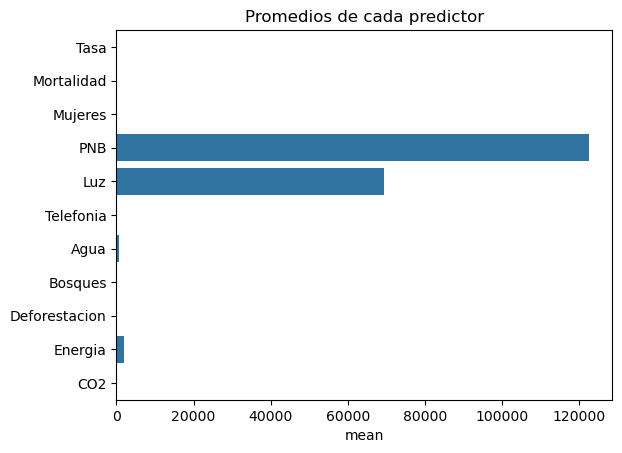

In [80]:
# graficamos las medias para vizualizar el rango de los datos
sns.barplot(data=desc.loc['mean', :], orient='h')
plt.title('Promedios de cada predictor')
plt.show()

Las variables `PNB` y `Luz` tienen valores promedios más altos que los demás, por lo que es necesario un escalamiento de las variables.

## Escalamiento de datos

In [81]:
# instanciamos el escalador
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
#transformamos a dataframe
X_df=pd.DataFrame(data=X_scaled, columns=X.columns)

## Gráficos globales


### Histograma

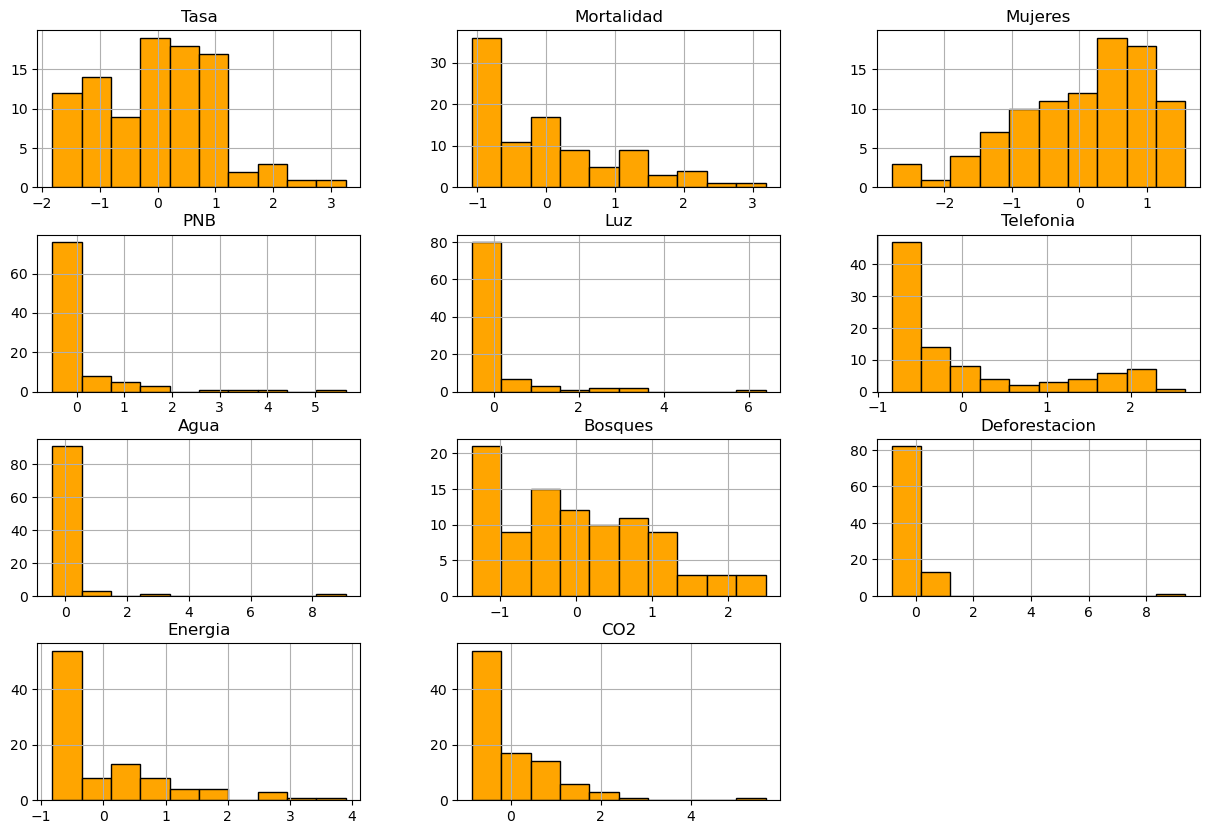

In [82]:
# generamos un hsitograma de las variables escaladas
X_df.hist(figsize=(15,10), edgecolor='black', color='orange')
plt.show()


### Boxplot

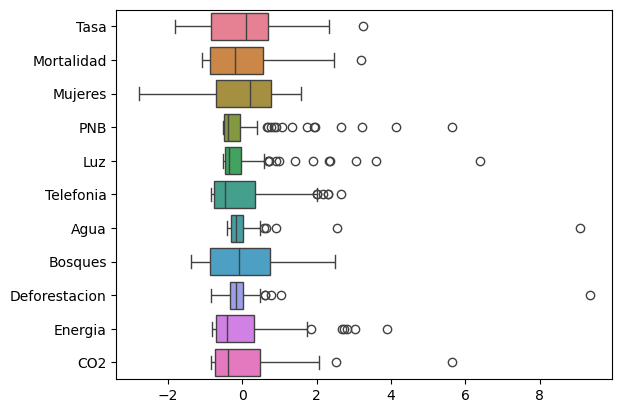

In [83]:
sns.boxplot(data=X_df, orient='h')
plt.show()

Tanto en el histograma com en la gráfica de cajas se muestra el comportamiento de los predictores. En el grupo de histogramas se puede apreciar que en las siguinetes variables:
- `PNB`
- `Luz`
- `Telefonía`
- `Agua`
- `Deforestación`
- `Energía`
- `CO2`

presetan un sesgo considerable ya que los datos no se encuentran distribuidos siguiendo una distribución normal.

El gráfico de cajas revela que dichos predictores contienen valroes atípicos, donde sobre salen: `PNB`, `Luz`y `Energía`. También es importante señalar que estos valores atípicos se encuentran por encima del valor máximo. Lo que indica que existen países con valores superiores al promedio.

### Correlaciones

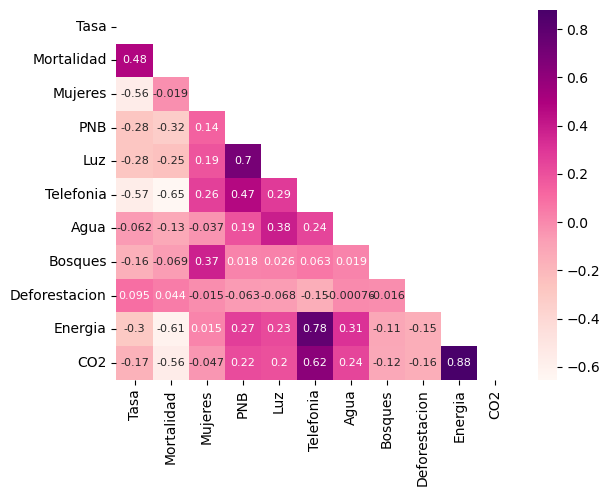

In [84]:
corr=X_df.corr()
# máscara para mostrar solo el triangulo superior
mask=np.triu(corr)
# matriz de correlaciones
sns.heatmap(data=corr, mask=mask, cmap='RdPu',annot=True, annot_kws={'size':8})
plt.show()

La correlación más fuerte la posee la variable `Energía` y `CO2`, esto indica que un aumento en el consumo de energía per cápita incrementa las emisiones de CO2, este incremento es característico de países en desarrollo en los que las principales fuentes de energía son no renovables.

Otra correlación positiva interesante es la que tiene la variable `Telefonía` con `CO2`y `Energía`, la cual parece indicar que paises con más líneas de teléfono activas son los que consumen más energía y pro lo tanto emiten más gases de efecto invernadero.

Por último, dentro de las correlaciones postivas, tenemos al relacionada con el `PNB` y `Luz`, claro indicador de que países con un producto interno bruto superior, producen grandes cantidades de energía eléctrica. 

Pasando a las correlaciones negativas, resaltan las demográficas: `Tasa` y `Mortalidad`.

- `Tasa` se relaciona principalmente con la variable `Mujeres`, esto parece indicar que el crecimiento de las poblaciones es inversamente proporcional con el procentaje de mujeres en dichas poblaciones. También e tiene una relación inversa considerable con `Telefonía`, esto puede interpretarse de la siguiente manera: la población femenina no tienen un acceso equitativo a las telecomunicaciones, esto puede deberse a factores sociales y culturales.
- `Mortalidad` está relacionado inversamente con `Telefonía` lo cual parce indicar que las poblaciones con una alta tasa de mortalidad no cuentan con acceso a telecomunciaciones, este indicador es caraterístico de países con un resago importante en el desarrollo, esta hipótesis se sutenta a su vez en la correlacón inversa con las variables `Energía` y `CO2`, en donde países con una alta tasa de mortalidad no son consumidores sustanciales de energías y tampoco emisores significativos de gases de efecto invernadero, eso conlleva a que al no ser países con una amplia infraestructura energética, no se cuenten mucho menos con los recursos para establecer una red de telecomunicaciones.

# PCA
Con el objetivo de redicr la dimensionalidad de la bases de datos se hará uso del método de componentes principales (`PCA`).

## Número óptimo de componentes
Antes de elegir un número arbitrario de componentes principales, conviene hacer un análsis sobre las varianzas explciadas para distinto número de componentes principales.

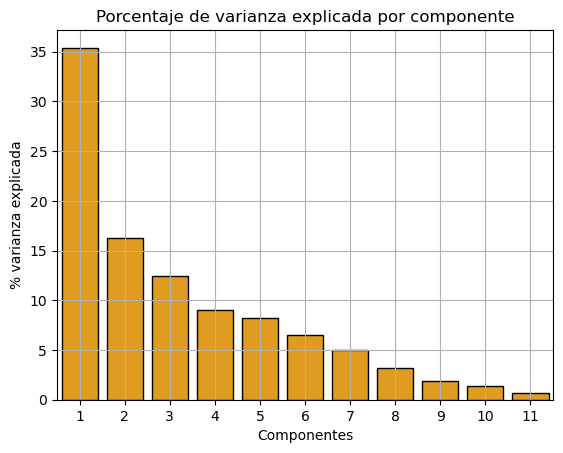

In [85]:
# instanciamos el modelo
n=11
pca=PCA(n_components=n, random_state=14)
pca.fit(X_df)
exp_var=np.round(pca.explained_variance_ratio_,3)*100

# graficamos las varianzas explicadas
sns.barplot(x=np.arange(1,n+1), y=exp_var, color='orange', edgecolor='black')
plt.xlabel('Componentes')
plt.ylabel('% varianza explicada')
plt.title('Porcentaje de varianza explicada por componente')
plt.grid(True)
plt.show()

La primer componente de PCA es la que contiene la mayor parte de la varianza explicada (alrededor de 35%), la segunda y tercera componente explican, cada una, poco más del 10% de la varianza explicada.

0 componentes representan 0.0 %
1 componentes representan 35.39 %
2 componentes representan 51.65 %
3 componentes representan 64.08 %
4 componentes representan 73.05 %
5 componentes representan 81.29 %
6 componentes representan 87.82 %
7 componentes representan 92.77 %
8 componentes representan 95.98 %
9 componentes representan 97.88 %
10 componentes representan 99.33 %


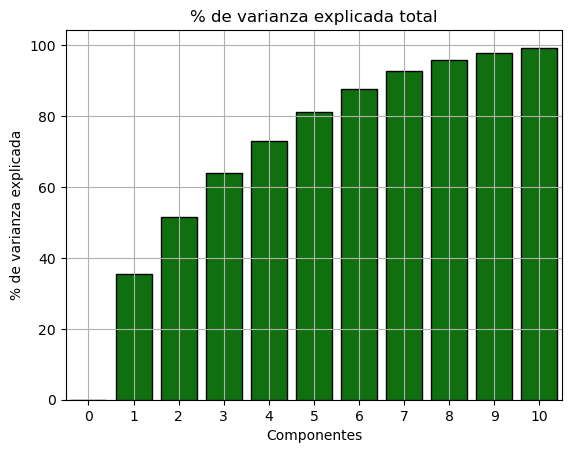

In [86]:
# suma de las varianzas explicadas

# vector para la suma de las varianzas explicadas
var_total=[]
for i in range(n):
    pca=PCA(n_components=i, random_state=14)
    pca.fit(X_df)
    total=pca.explained_variance_ratio_.sum()*100
    var_total.append(total)
    print(f'{i} componentes representan {round(total,2)} %')
# graficamos
sns.barplot(x=np.arange(n), y=var_total, edgecolor='black', color='green')
plt.xlabel('Componentes')
plt.ylabel('% de varianza explicada')
plt.title('% de varianza explicada total')
plt.grid(True)
plt.show()

Tomar 5 predictores de PCA nos garantiza poco más de 80% de la varianza total explicada. La elección para el posterior análsis será de 6 componentes con un aproximado de 88%.

In [87]:
# tomando 6 componentes
n=6
pca=PCA(n_components=n, random_state=14)
# generamos las nuevas variables transofmradas
X_pca_trans=pca.fit_transform(X_df)
# convertimos a data frame
X_pca=pd.DataFrame(data=X_pca_trans, columns=[f'PC{i}' for i in range(1,n+1)])

X_pca.head()



,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.776040,1.374755,-0.909597,-0.181262,0.454276,0.488905
1,-2.463113,0.602578,0.233562,-0.644256,0.117073,-1.193507
2,0.242463,-3.968445,0.752330,-0.339541,-0.227962,1.161158
3,-1.149461,-1.549521,0.296334,-0.194766,-0.808079,0.088240
4,0.372177,-0.204503,0.405486,-0.229591,-0.387988,0.264560


## Carga por componentes
Para interpretar las componentes generadas podemos extraer los coeficientes de cada componente, esto indica el *peso* que tiene cada predictor.

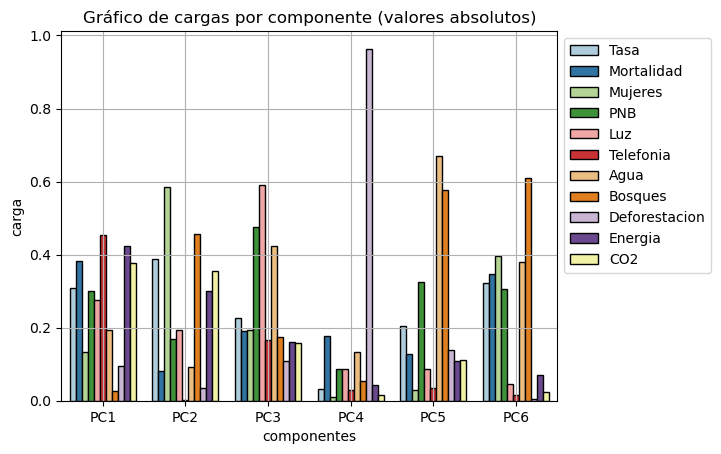

In [88]:
# extraemos las componentes
pca_components=pca.components_
# transformamos a dataframe
loadings=pd.DataFrame(pca_components.T,
                      columns=[f'PC{i}' for i in range(1,n+1)],
                      index=X_df.columns
)

# graficamos los pesos

# pasamos a formato largo 
loadings_long=loadings.reset_index().melt(
    id_vars='index',
    var_name='columna',
    value_name='valor'
)

# renombramos las columnas
loadings_long.rename(columns={'index': 'predictores',
                             'columna':'componentes',
                             'valor':'carga'
                             },
                             inplace=True
                    )

# reemplazamos por el valor absoluto 
loadings_long['carga']=loadings_long['carga'].abs()

# graficamos por cada componente, ordenando por carga
sns.barplot(
    data=loadings_long,
    x='componentes',
    y='carga',
    hue='predictores',
    palette='Paired',
    edgecolor='black'
)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(True)
plt.title('Gráfico de cargas por componente (valores absolutos)')
plt.show()

Notemos que la mayoría de las variables son capturadas por las tres pirmeras componentes, a excepción de `Bosques`, `Agua` y `Deforestación`, que adquieren mayor relavancia en las componentes 4, 5 y 6.

Las componentes obtenidas no parecen tener una relación lógica o causal con los predcitores originales. Esto es normal ya que `PCA` no le importa la relación semántica entre las variables, solo se centra en buscar direcciones de máxima varianza.

## Datos con PCA

In [89]:
# creamos una un data frame con las componentes PCA y los paises
data_pca=pd.concat((paises, X_pca), axis=1)
data_pca

,Pais,PC1,PC2,PC3,PC4,PC5,PC6
0,Albania,-0.776040,1.374755,-0.909597,-0.181262,0.454276,0.488905
1,Angola,-2.463113,0.602578,0.233562,-0.644256,0.117073,-1.193507
2,Arabia Saudi,0.242463,-3.968445,0.752330,-0.339541,-0.227962,1.161158
3,Argelia,-1.149461,-1.549521,0.296334,-0.194766,-0.808079,0.088240
4,Argentina,0.372177,-0.204503,0.405486,-0.229591,-0.387988,0.264560
...,...,...,...,...,...,...,...
91,Venezuela,-0.051288,-0.069298,-0.300310,0.214019,0.719595,1.259621
92,Vietnam,-1.196673,1.045716,-0.317127,0.060755,-0.028759,-0.545265
93,Yemen,-2.667427,-1.285497,0.835140,-0.754276,0.011358,-0.261827
94,Zambia,-2.153095,1.187690,-0.038407,-0.378465,0.720152,-0.398612


# Clustering
En esta sección aplicaremos técnicas de clustering a los datos obtenidos con PCA y a los datos originales para comprara la efectividad de cada algoritmo.

## `K-means`
Ya que el análisis PCA produce componentes ortogonales y de escala continua, es aporpiado emplear el método de clustering K-means.

Este algoritmo necesita establecer un número óptimo de clusters, para ello usaremos la métrica `silhouette_score` para medir la calidad de los clsuters generados. Recordemos que para esta métrica el valor óptimo para el número de clusters debe ser de 1, mientras que -1 representa la calidad más baja en lso clusters; valores cercanos a 0 indican superposición de clústers.

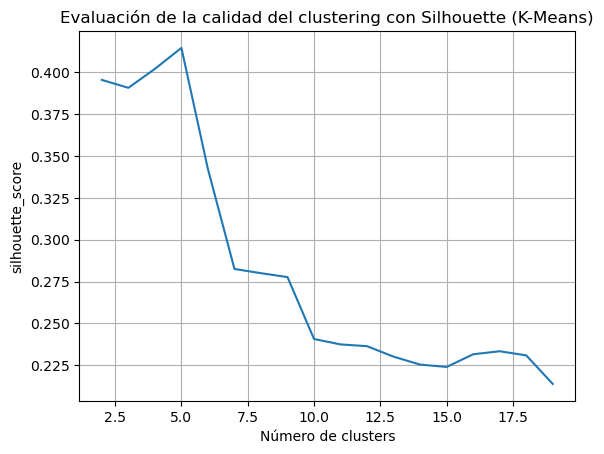

In [90]:
# definimos un número máximod e clusters
n_max=20
# definimos un arreglo para guardar las los valores de la métrica
sh_scores=[]

for i in range(2, n_max):
    #iniciamos el modelo
    km=KMeans(n_clusters=i, random_state=14)
    # calculamos el puntaje
    sh=silhouette_score(X_pca, km.fit_predict(X_pca))
    sh_scores.append(sh)
    
# graficamos
sns.lineplot(x=np.arange(2, n_max), y=sh_scores, markers=True)
plt.xlabel('Número de clusters')
plt.ylabel('silhouette_score')
plt.grid(True)
plt.title('Evaluación de la calidad del clustering con Silhouette (K-Means)')
plt.show()

De acuerdo al gráfico anterior, el número óptimod e clusters para usarse con `PCA`y `K-Means` es de 5.

In [91]:
best_km=KMeans(n_clusters=5, random_state=14)
# obtenemos las etquetas
km_labels=best_km.fit_predict(X_pca)

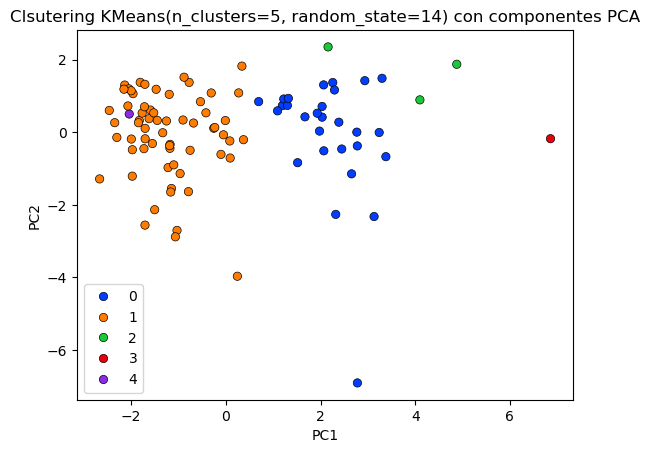

In [92]:
# graficamos los clusters junto a las dos primeras componentes de PCA
sns.scatterplot(
    x=X_pca['PC1'], 
    y=X_pca['PC2'], 
    hue=km_labels,
    edgecolor='black',
    palette='bright'
)
plt.title(f'Clsutering {best_km} con componentes PCA')
plt.show()

Se pueden observar dos regiones principales, correspondientes a los clústers 0 y 1, los clusters 2, 3, y 4 no se encuentran bien definidos, incluso mezclados con los clusters princpiales.

Para comprobar la efectividad de este modelo, vamos a graficar un `pair_plot()` con las variables originales.

### Pairplot

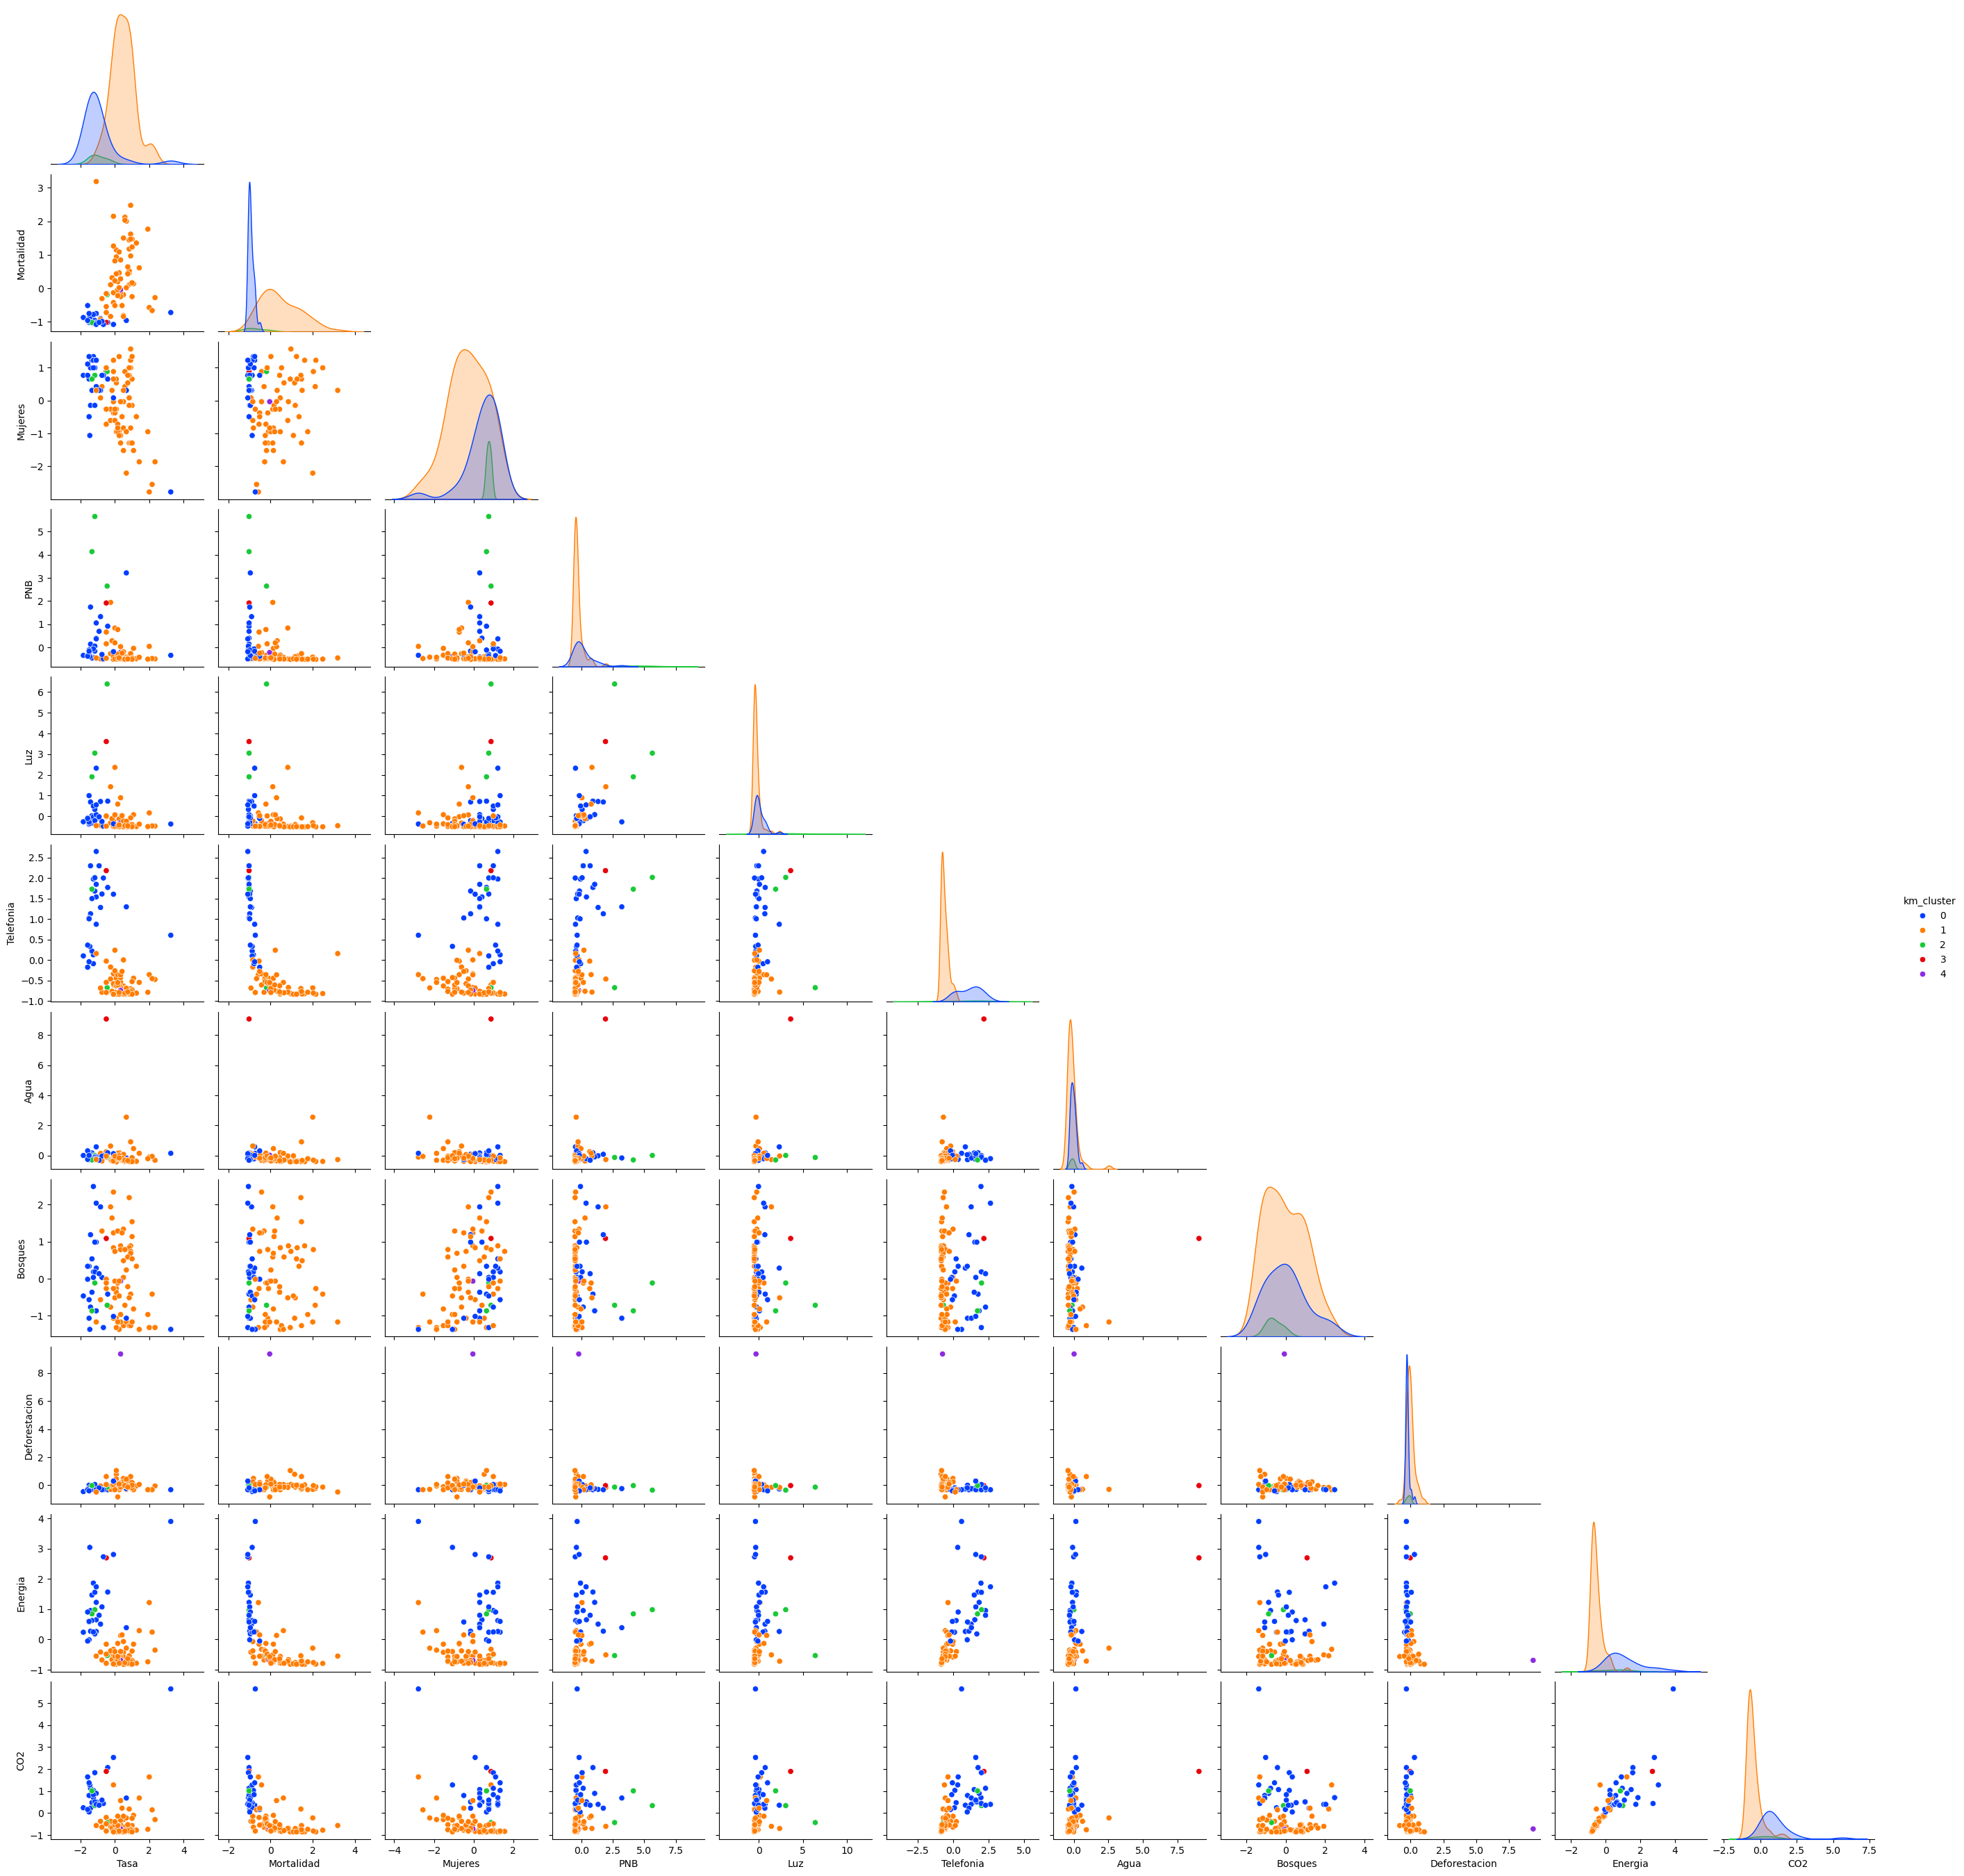

In [93]:
# creamos una copia del dataframe con los datos escalados
X_km=X_df.copy()
# agregamos la columna de los valores del cluster
X_km['km_cluster']=km_labels

# graficamos
sns.pairplot(data=X_km, hue='km_cluster', corner=True, palette='bright')
plt.show()


## Agglomerative clustering
El Agglomerative Clustering resulta útil para descubrir patrones jerárquicos y relaciones de proximidad dentro de un conjunto de datos, lo que lo convierte en una herramienta ampliamente utilizada en el análisis exploratorio.


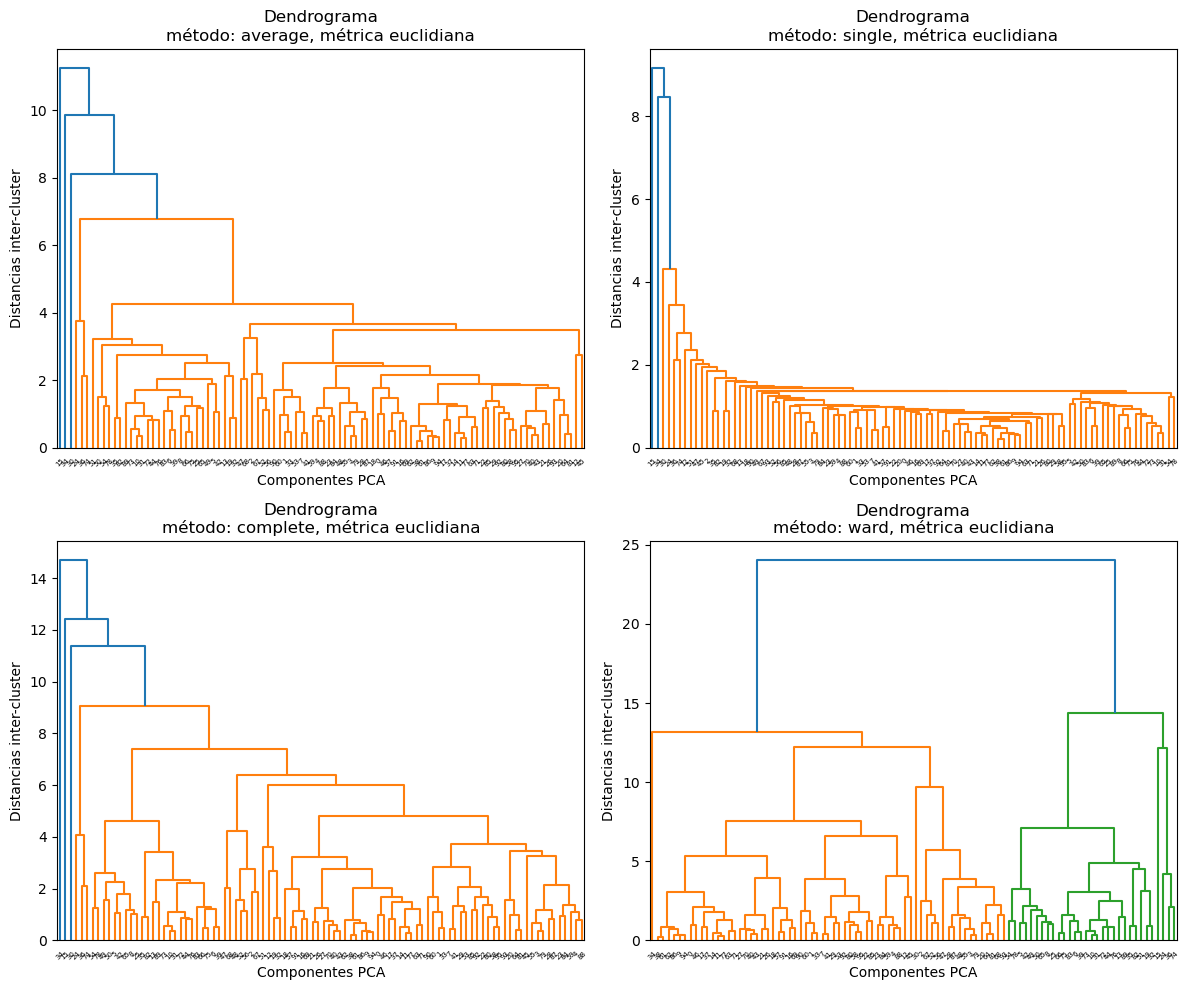

In [94]:
# Instanciamos el modelo
agg=AgglomerativeClustering()

# métodos
methods=['average', 'single', 'complete', 'ward']

# creamos la figura con subplots (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# aplanamos los ejes para iterar fácilmente
axes = axes.flatten()

for ax, method in zip(axes, methods):
    sch.dendrogram(
        sch.linkage(X_pca, method=method, metric='euclidean'),
        ax=ax
    )
    ax.set_title(f'Dendrograma\nmétodo: {method}, métrica euclidiana')
    ax.set_xlabel('Componentes PCA')
    ax.set_ylabel('Distancias inter-cluster')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Como se muestra en los dendrogramas, la estructura jerárquica muestra que se puede cortar el árbol a una distancia de 14 forma dos grupos bien definidos. Para comprobar el número de clusters óptimo mediremos la separación entre cúmulos usando la media de Silhouette.

### Evaluación de linkages

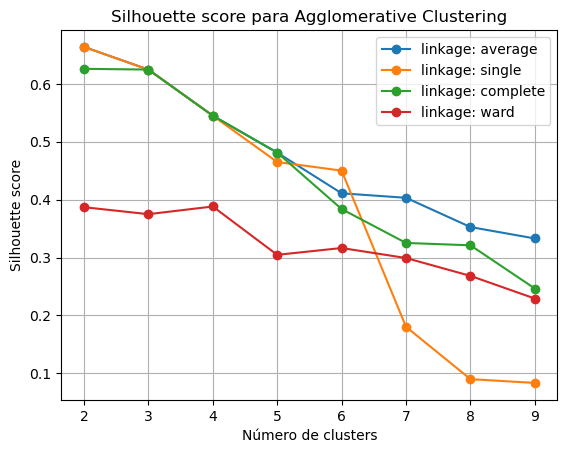

In [95]:
# número de clusters para probar
clusters=np.arange(2,10)

for i in methods:
    # Arreglo donde se guardarán las medias de Sihoulette
    sh_mean=[]
    for j in clusters:
        agg=AgglomerativeClustering(n_clusters=j, linkage=i)
        # ajustamos el mdoelo 
        agg.fit(X_pca)
        # obtenemos las etiquetas
        labels=agg.fit_predict(X_pca)
        # media de Sihoulette
        sh_value=silhouette_score(X_pca, labels)
        # agergamos al arreglo
        sh_mean.append(sh_value)
    plt.plot(clusters, sh_mean, marker='o', label=f'linkage: {i}')
plt.grid(True)
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette score para Agglomerative Clustering')
plt.legend()
plt.show()

Los cuatro linkage tienen un valor máximo en 2 clusters, sin embargo esto no modela correctamente los datos, por lo que tomaremos el segundo valor máximo, en este caso, la elección será `linkage=ward` con `n_clusters=4`.

In [222]:
best_agg=AgglomerativeClustering(n_clusters=4, linkage='ward')
# obtenemos las etiquetas
agg_labels=best_agg.fit_predict(X_pca)

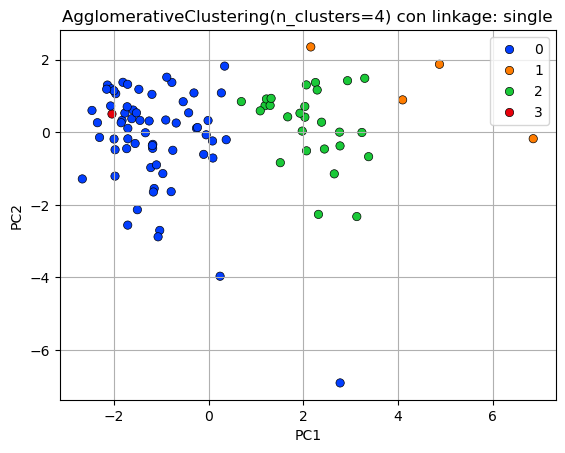

In [223]:
# graficamos las dos primeras componentes con las etiquetas encontradas
sns.scatterplot(
    x=X_pca['PC1'],
    y=X_pca['PC2'],
    hue=agg_labels,
    edgecolor='black',
    palette='bright'
)
plt.title(f'{best_agg} con linkage: single')
plt.grid(True)
plt.show()

Como podemos osbservar para las dos primeras componentes de PCA, este modelo de clustering no logra separar de manera satisfactoria los datos con 8 clusters, si bien tiene un puntaje de Silhouette óptimo para ese número de clusters, no garantiza que aporten un aexplicación satisfactoria a estas agrupaciones.

### Pairplot

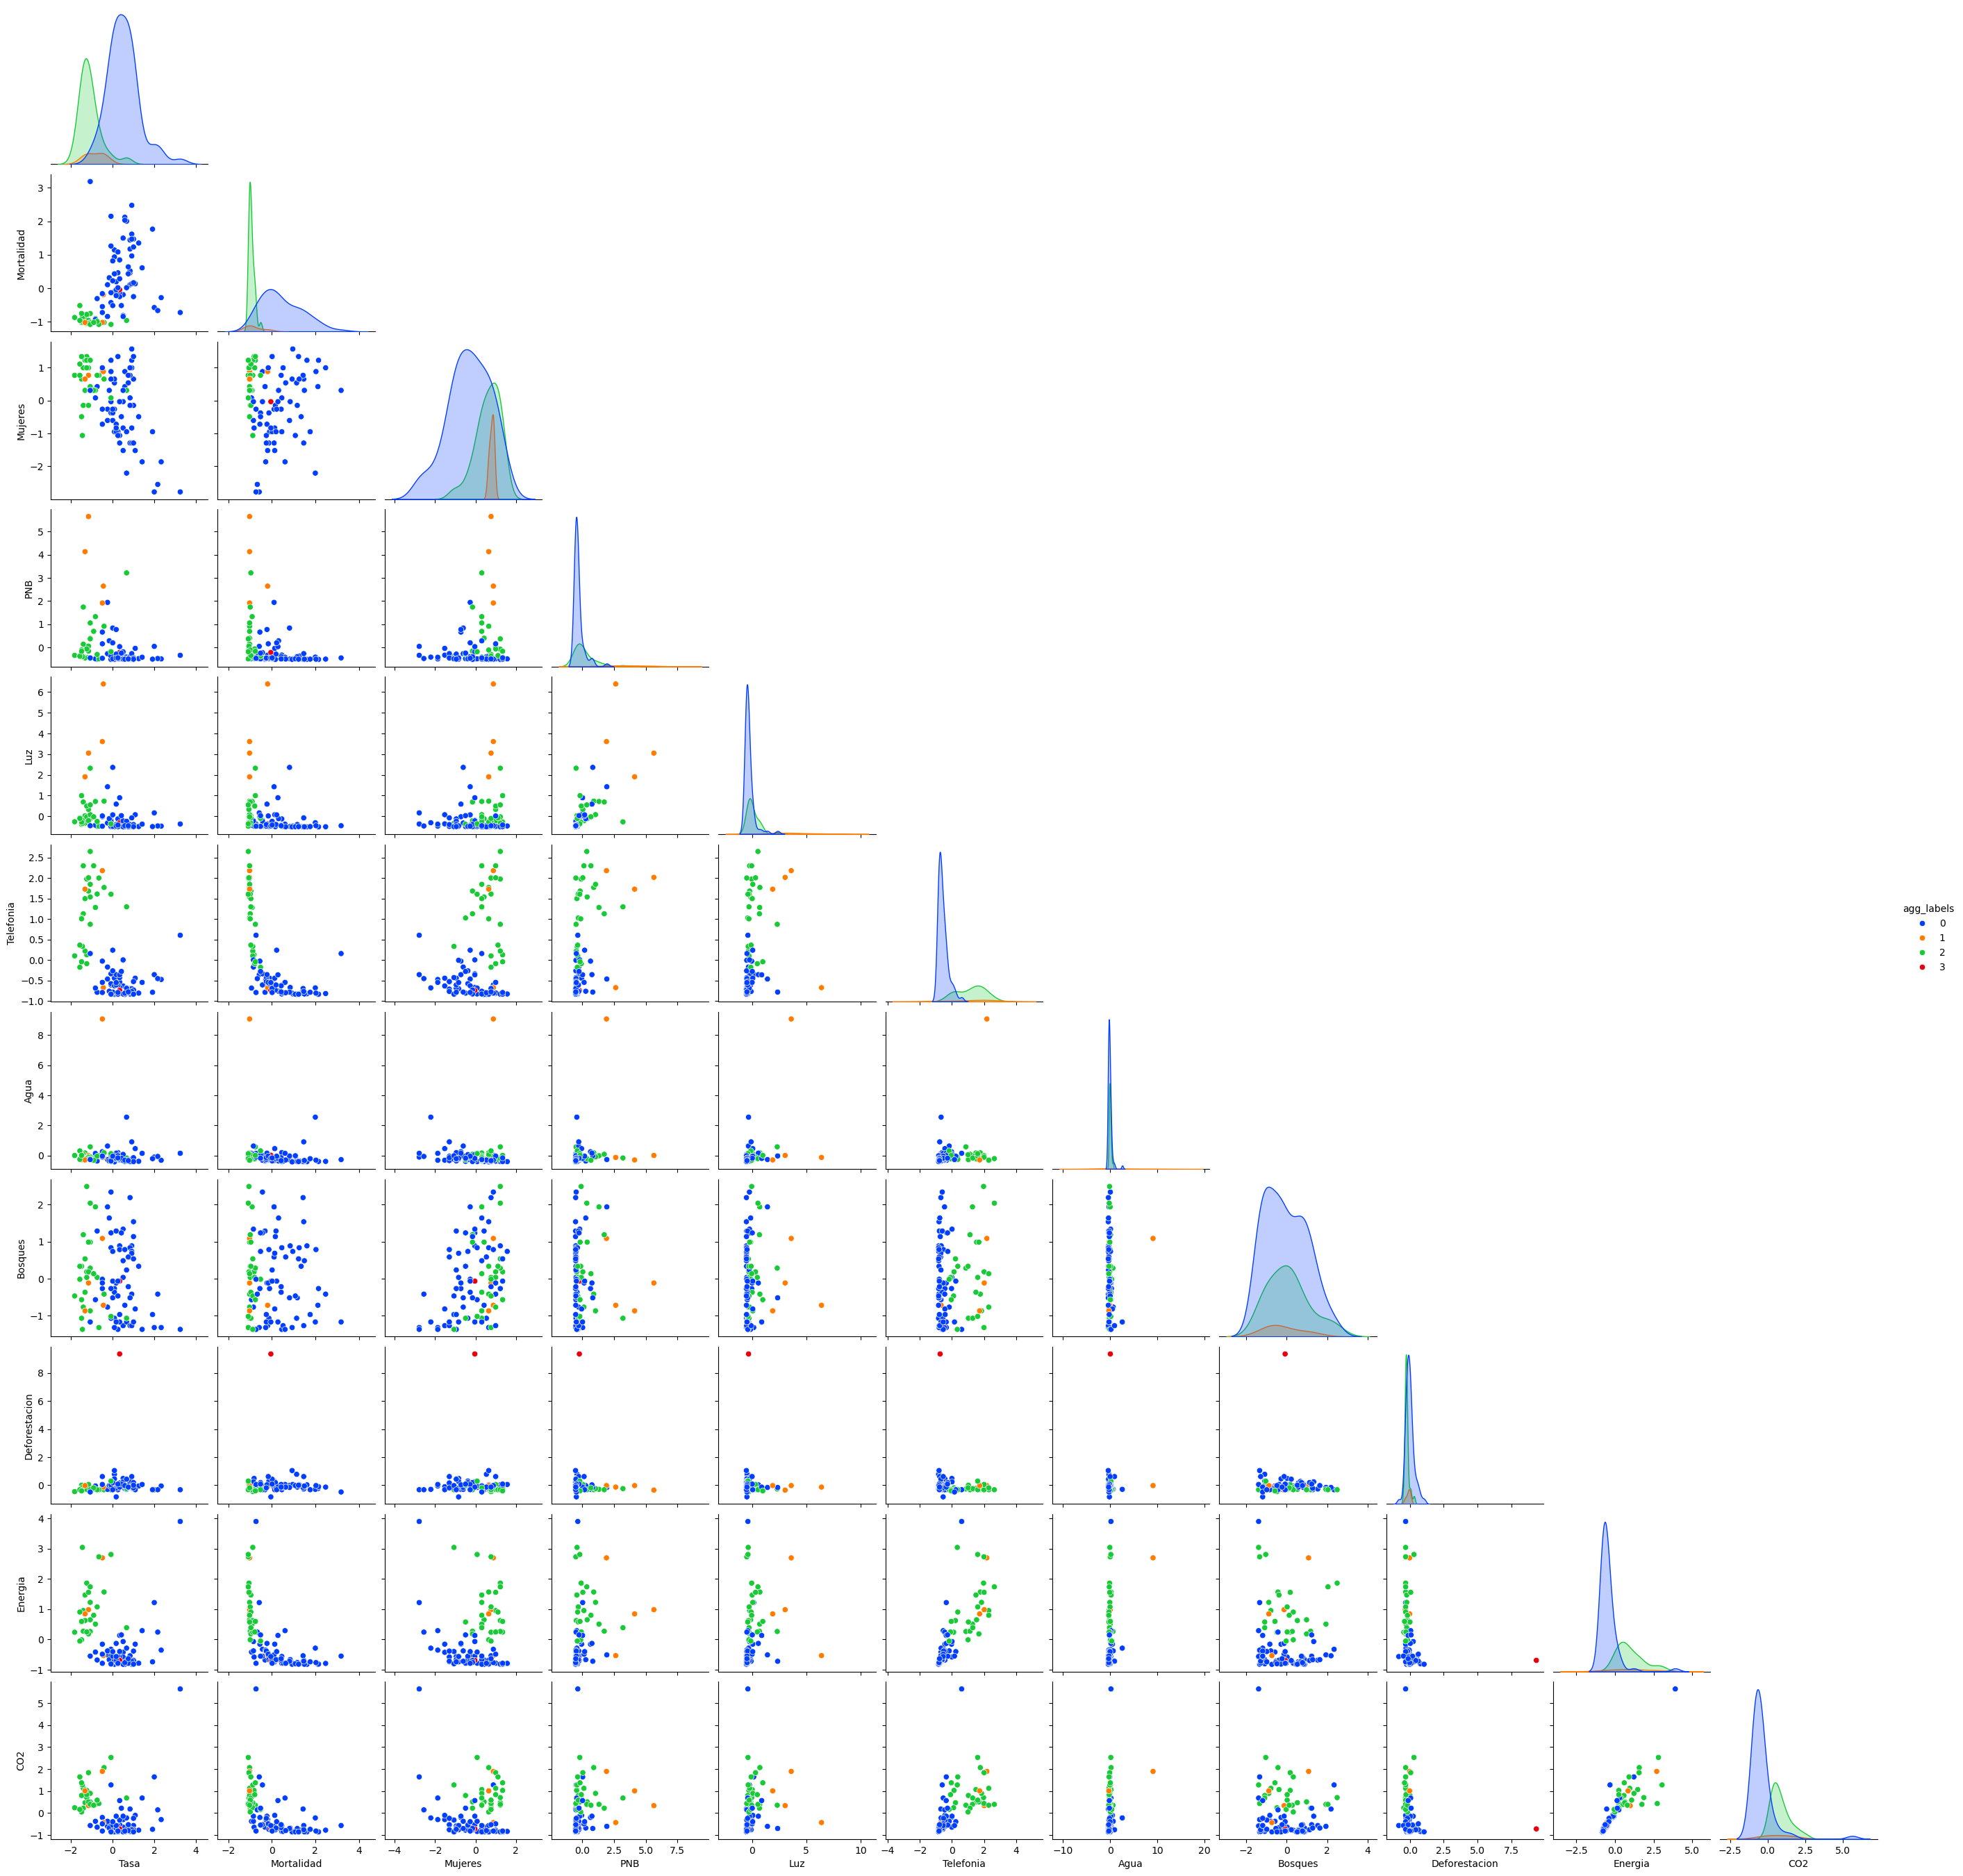

In [224]:
X_agg=X_df.copy()
X_agg['agg_labels']=agg_labels

sns.pairplot(
    data=X_agg,
    hue='agg_labels',
    palette='bright',
    corner=True
)
plt.show()

## DBSCAN

El algoritmo DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un método de clustering basado en densidad que identifica grupos de puntos con alta concentración, separándolos de regiones de baja densidad consideradas como ruido. Su principal fortaleza radica en que no requiere especificar el número de clusters previamente y es capaz de detectar formas arbitrarias en los datos, incluso en presencia de outliers. Sin embargo, su desempeño depende fuertemente de la elección adecuada del parámetro ε (epsilon), que define el radio de vecindad para considerar la densidad; valores inadecuados pueden conducir a un exceso de fragmentación o a la unión artificial de clusters.



### Búsqueda de epsilon
Para efectuar la búsqueda de un valor $\epsilon$ haremos uso del algoritmo `NearestNeighbors`. Tomando como valor inicial de vecinos $n=\sqrt{\text{total de observaciones}}$, en este caso el número de observaciones es de 95. Por lo tanto tomaremos 9 vecinos aproximadamente.

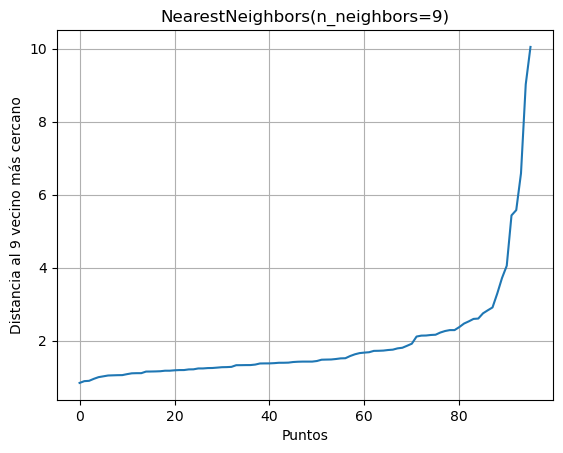

In [98]:
# definimos el número de vecinos cercanos
n_neighbors=9
# instanciamos le modelo 
nn=NearestNeighbors(n_neighbors=n_neighbors)
# entrenamos el modelo
nn.fit(X_pca)
# obtenemos las distancias
dsitances, _=nn.kneighbors(X_pca)
# de las tres distancias incluyendo el origen, tomamos la última ya que es la más lejos
distances=np.sort(dsitances[:,n_neighbors-1])

# graficamos 
plt.plot(distances)
plt.title(nn)
plt.xlabel('Puntos')
plt.ylabel(f'Distancia al {n_neighbors} vecino más cercano')
plt.grid(True)
plt.show()

Si tomamos los 3 vecinos más cercanos, la distancia máxima es de aproximadamente 2.1, después de ese valor los clusters se encuentran más alejados de sí.


In [244]:
# instanciamos el moelo
db=DBSCAN(eps=3)
# obtenemos las etiquetas
db_labels=db.fit_predict(X_pca)

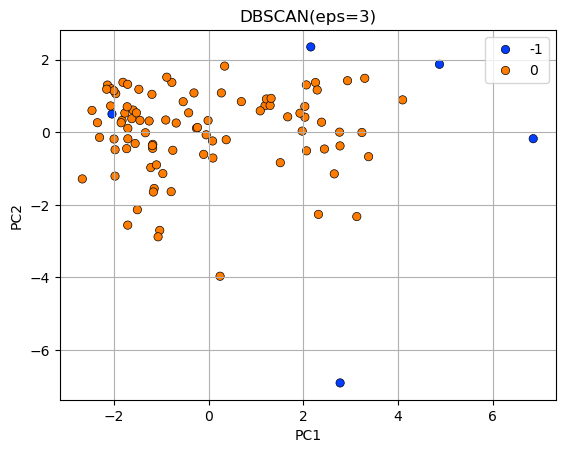

In [245]:
# graficamos las dos primeras componentes con las etiquetas encontradas
sns.scatterplot(
    x=X_pca['PC1'],
    y=X_pca['PC2'],
    hue=db_labels,
    edgecolor='black',
    palette='bright'
)
plt.title(f'{db}')
plt.grid(True)
plt.show()

Para las dos primeras componentes de `PCA`, `DBSCAN` identificó dos clusters, el que se etiquetó con $-1$ representa los valores atípicos. En este estudio no es conveniente eliminar los datos atípicos ya que represetnan países.

Con el fin de visualizar los conjuntos generados, generaremos un `pairplot` del dataframe escalado junto a estas etiquetas.

### Pairplot

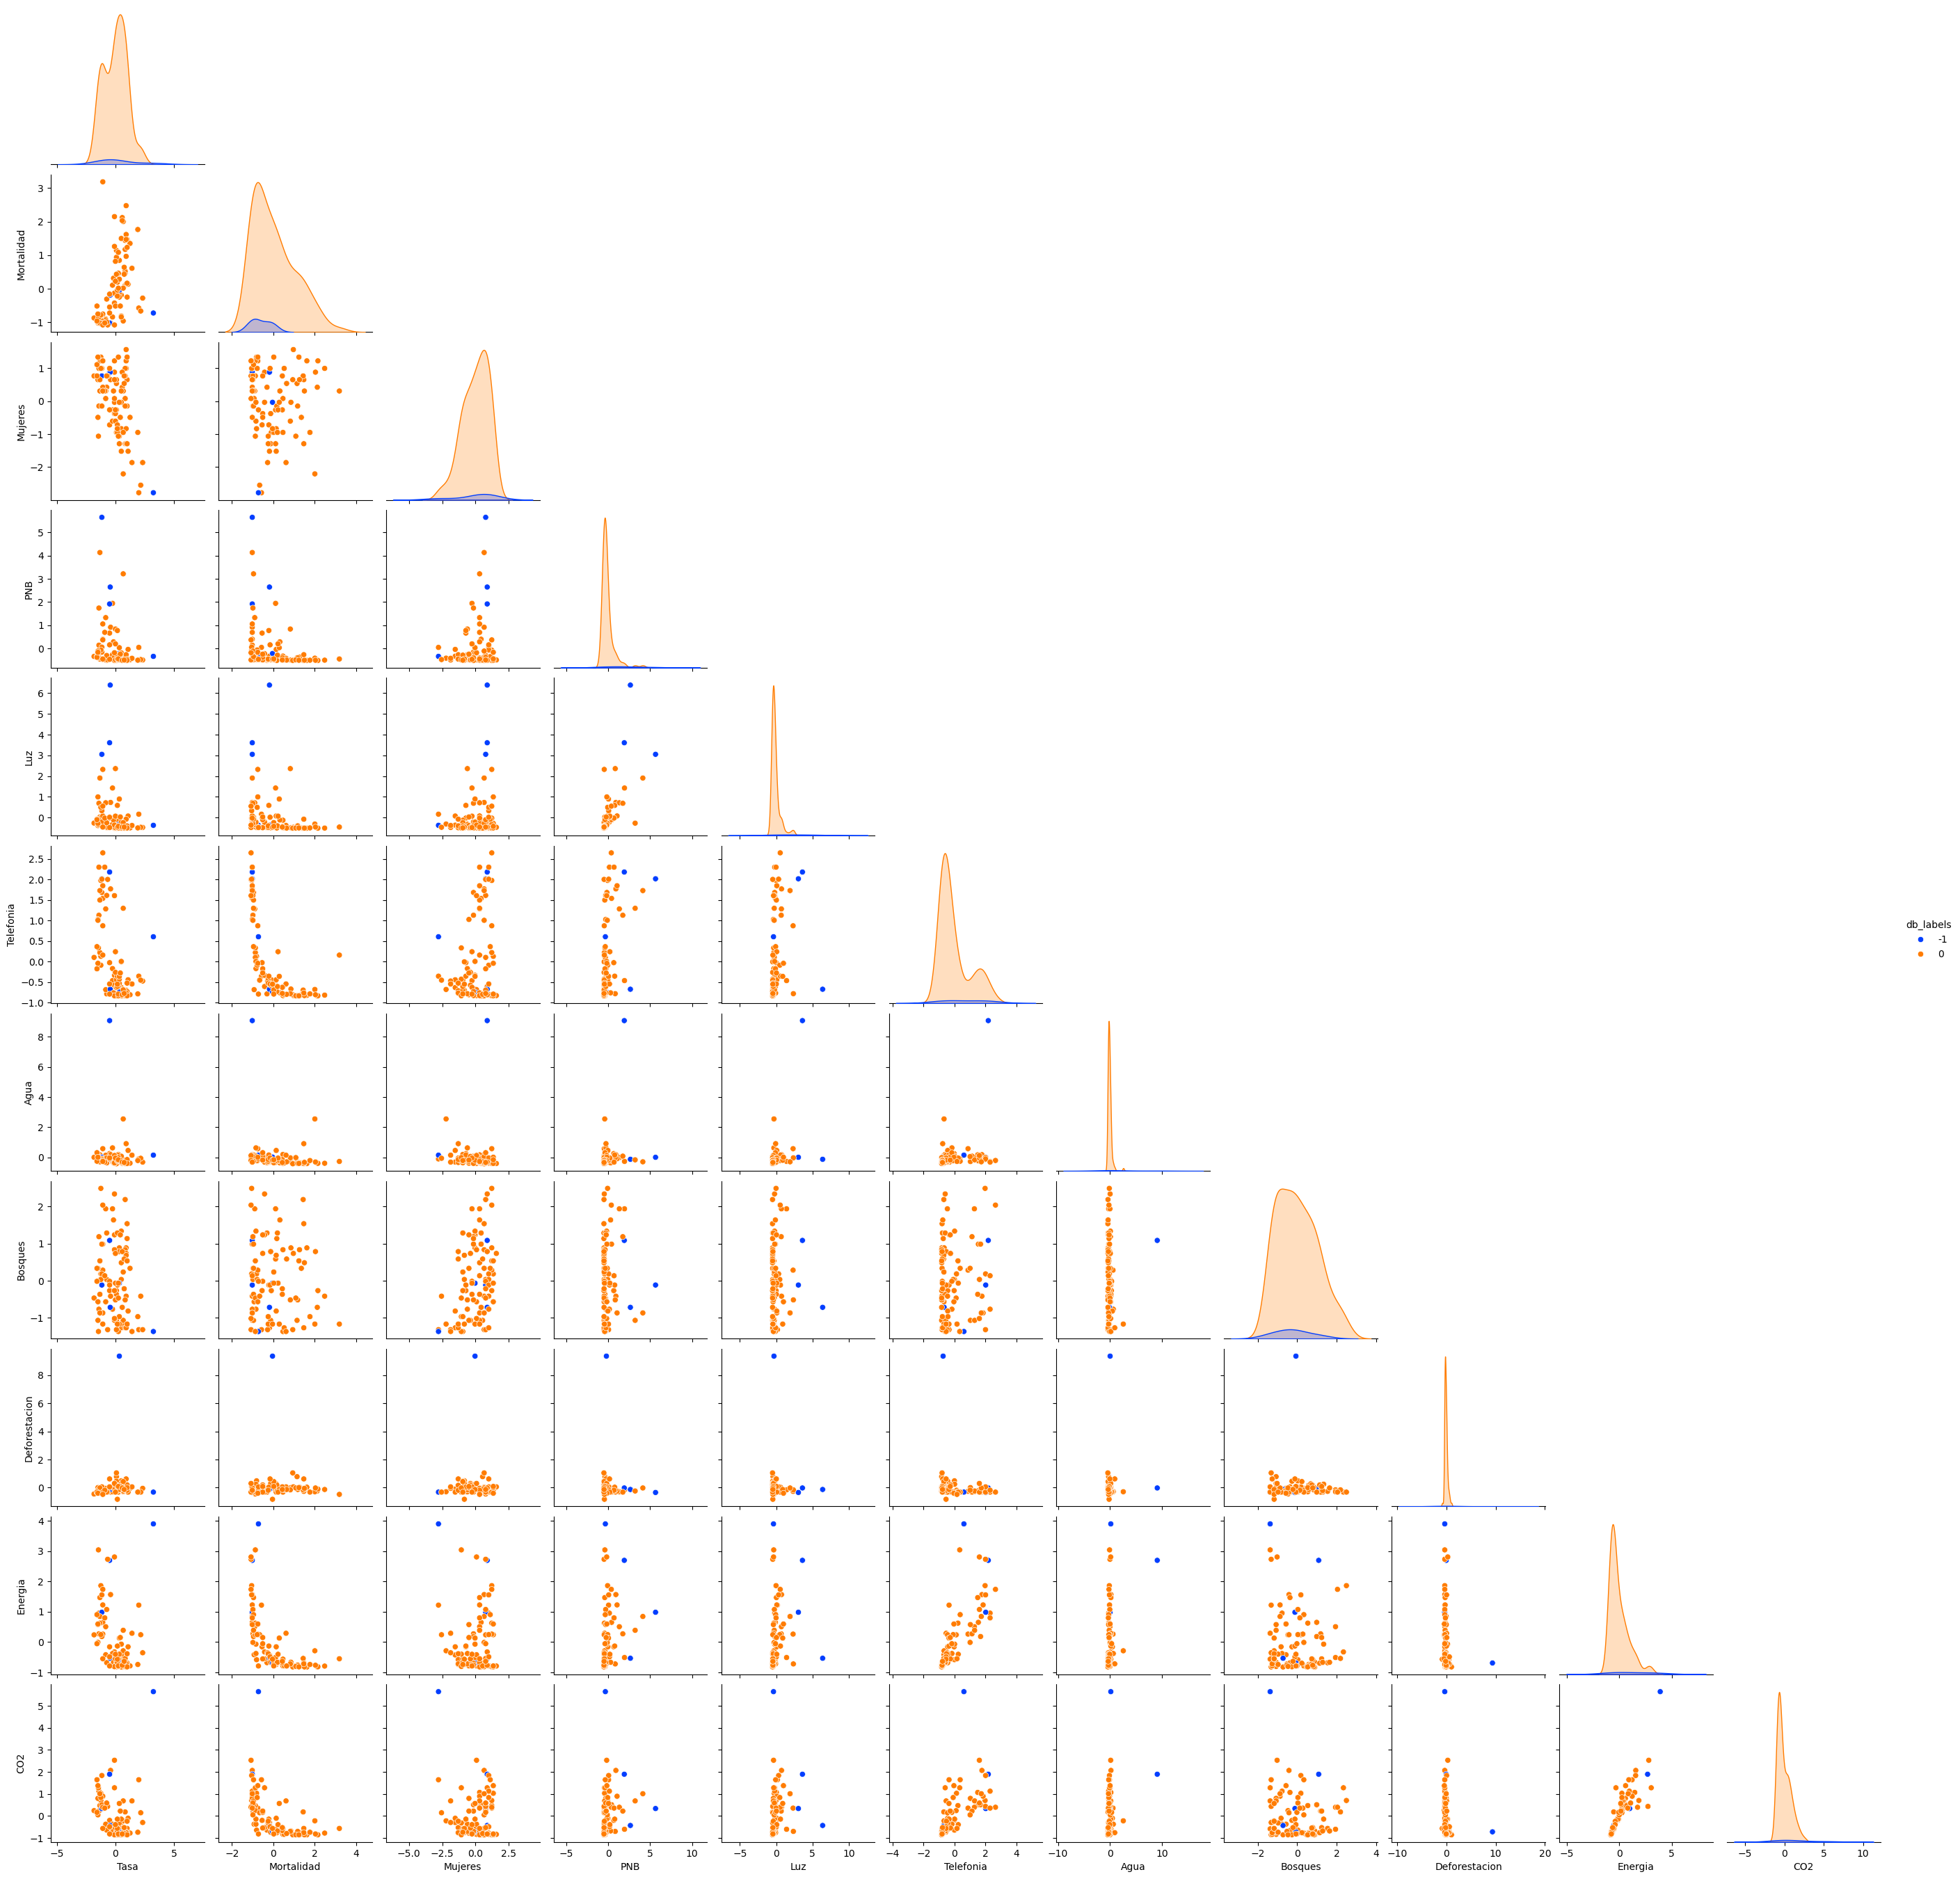

In [101]:
# copiamos el dataframe
X_dbscan=X_df.copy()
# agregamos la columna de las 
X_dbscan['db_labels']=db_labels

# graficamos el pairplot
sns.pairplot(
    data=X_dbscan, 
    hue='db_labels',
    palette='bright',
    corner=True
)
plt.show()

## Affinity clsutering
Es un algoritmo de clsutering basado en la propagación de afinidades entre pares de puntos.
- A deiferencia de `K-Means` o `Agglomerative`, no se necesita definir el número de clusters.
- El algoritmo decide automáticamente cuántos clusters formar, basándoes een que puntos son mas representativos (llamados *exemplars*).

El hiperparámetro `preference` define que tan probale es que un punto sea un exemplar. Para elegir el mejor valor haremos una evaluación usando la métrica de Silhouette.

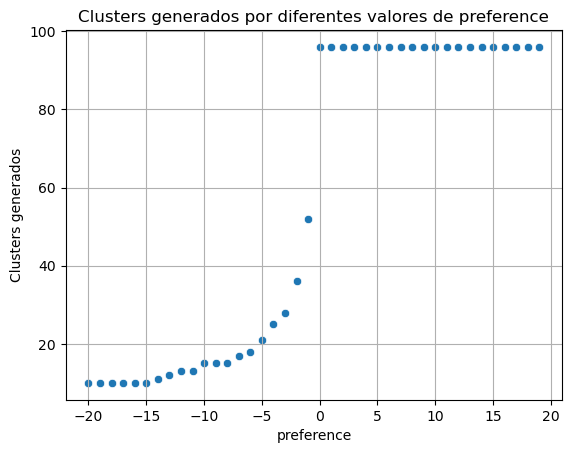

In [123]:
# arreglo para las puntuaciones
sh_scores=[]
# clusters gnerados en cada iteración
clusters=[]
# número máximo de preferences
n_pref=20
# iteramos con un ciclo for 
for i in range(-n_pref, n_pref):
    # inicializamos el modelo 
    aff=AffinityPropagation(preference=i, random_state=14)
    aff.fit(X_pca)
    aff_labels=aff.predict(X_pca)

    # verificamos si se generaron clusters
    clusters_generated=len(set(aff_labels))
    # guardamos los clusters generados
    clusters.append(clusters_generated)
    
# graficamos las preferences vs los clusters generados
sns.scatterplot(
    x=range(-n_pref, n_pref),
    y=clusters
)
plt.xlabel('preference')
plt.ylabel('Clusters generados')
plt.title('Clusters generados por diferentes valores de preference')
plt.grid(True)
plt.show()

El rango de `preference` se encuentra en los valores enteros menores que cero, como se puede observar en la gáfica de arriba, ya que para valores mayores que cero, el algoritmo crea clsuters individuales por cada registro lo cual no puede ser evaluado mediante la métrica de Silhouette. En el siguiente paso evaluaremos la calidad de esos clusters en el rango antes encontrado.

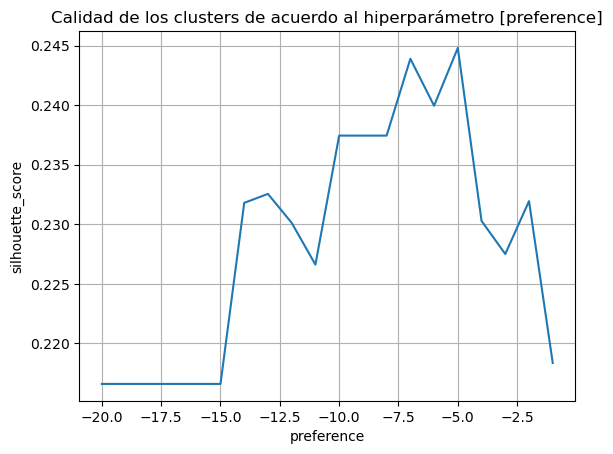

In [132]:
# valor máximo óptimo
pref_opt_range=20

# arreglo para guardar la métrica de silhouette
sh_scores=[]

# recorremos con un ciclo for
for i in range(-pref_opt_range, 0):
    aff=AffinityPropagation(preference=i, random_state=14)
    aff.fit(X_pca)
    aff_pred=aff.predict(X_pca)
    # evaluamos la calidad de las predicciones
    sh=silhouette_score(X_pca, aff_pred)
    # guardamos
    sh_scores.append(sh)

# graficamos
sns.lineplot(
    x=np.arange(-pref_opt_range, 0),
    y=sh_scores
)
plt.grid(True)
plt.xlabel('preference')
plt.ylabel('silhouette_score')
plt.title('Calidad de los clusters de acuerdo al hiperparámetro [preference]')
plt.show()

La métrica de Silhouette indica que el valor óptimo de `preference` es -5 ya que se alcanza el valor máximo en dicho valor. Sin embargo, para este valor de `preference`se tienen aproximadamente 20 clusters, lo cual puede llevar a un sobre ajsute de los datos. En este caso tomaremos el primer pico (de izquerda a derecha) como la elección del valor de preferencia: 12.

In [238]:
# Generamos los clusters con el valor óptimo de preference

aff=AffinityPropagation(preference=-12, random_state=14)
# obtenemos las etiquetas
aff.fit(X_pca)
aff_labels=aff.predict(X_pca)

# pasamos los datos aun dataframe para visualizar
X_aff=X_df.copy()

# agregamos las eitquetas
X_aff['aff_labels']=aff_labels

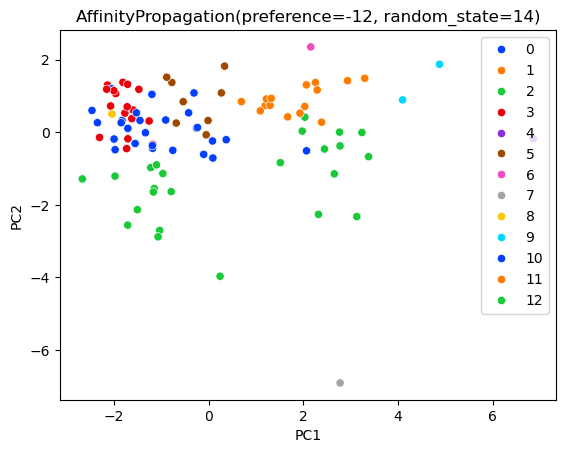

In [239]:
# graficamos las dos primeras componentes de PCA
sns.scatterplot(
    x=X_pca['PC1'],
    y=X_pca['PC2'],
    hue=aff_labels,
    palette='bright'
)
plt.title(aff)
plt.show()

### Pairplot

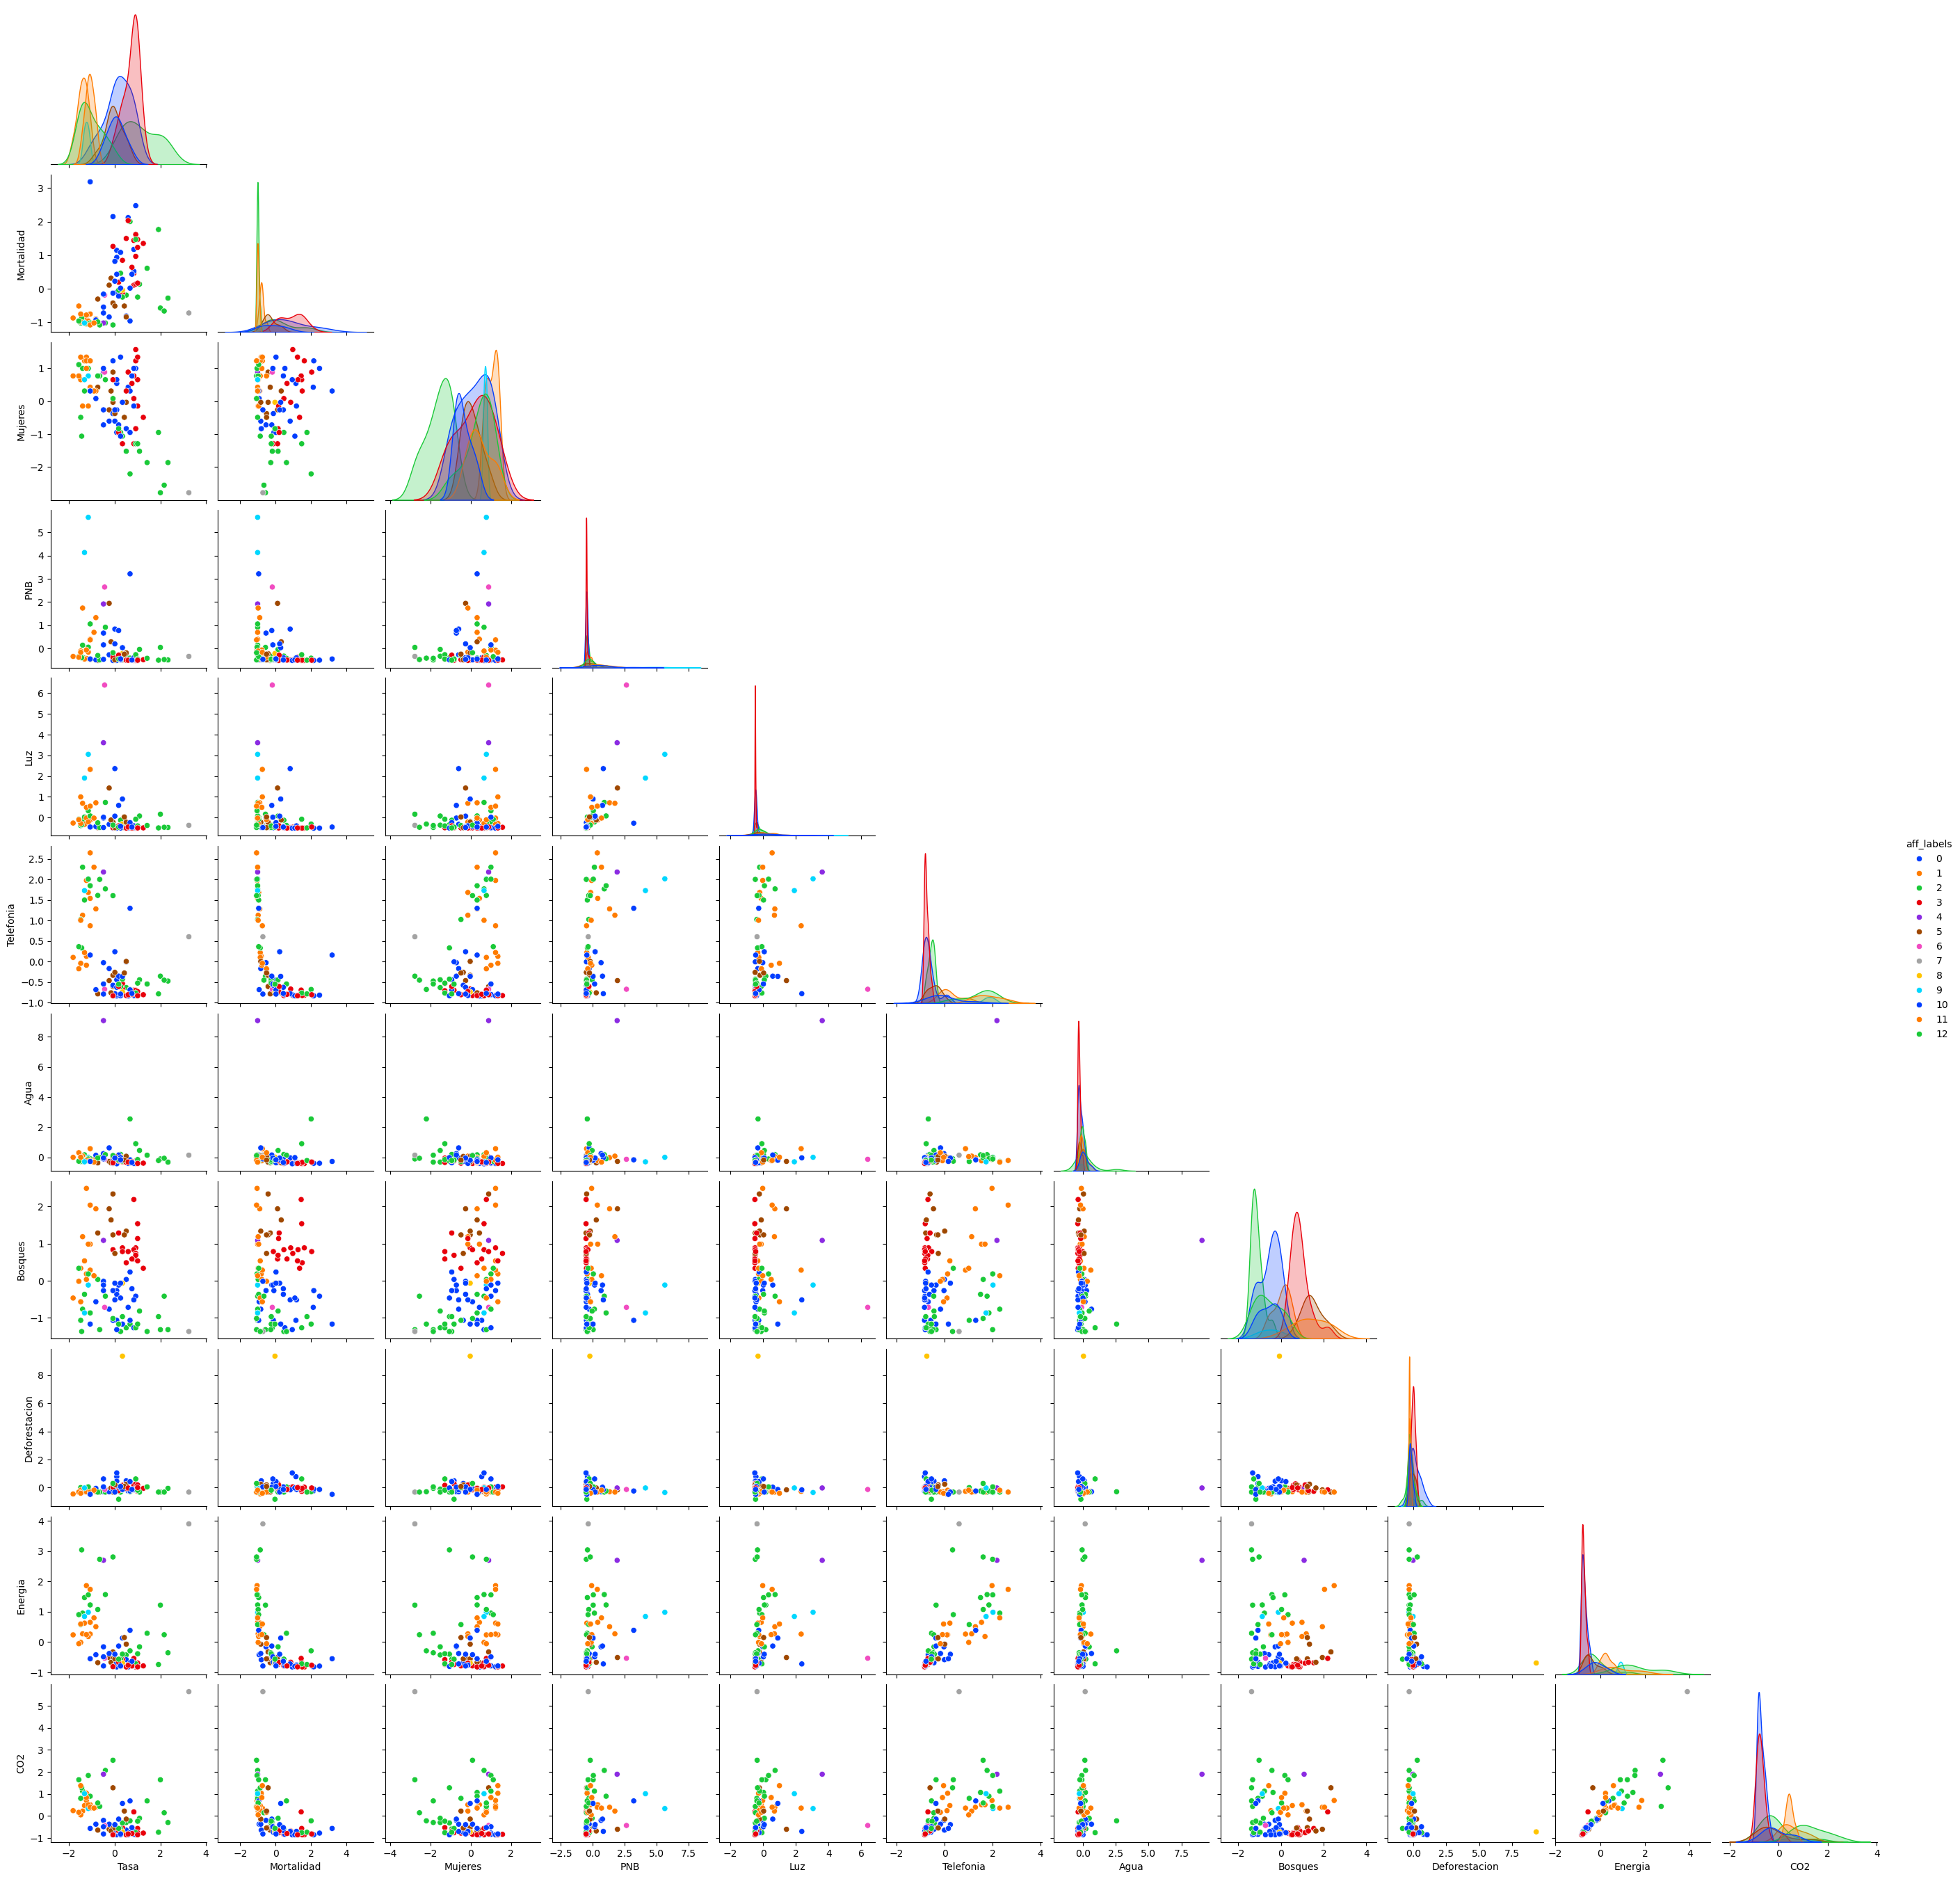

In [240]:
# Clusters par las variables originales
sns.pairplot(
    data=X_aff,
    hue='aff_labels',
    corner=True,
    palette='bright'
)
plt.show()

## Mezclas gaussianas
Un GMM es un modelo probabilístico que asume que los datos provienen de varias distribuciones normales (gaussianas) superpuestas.

- Cada cluster se modela como una gaussiana multivariante con su propia media y covarianza.

- La idea es que cada punto tiene cierta probabilidad de pertenecer a cada cluster, no una asignación estricta.

**Elementos clave**
1. **Número de clusters (n_components)**  
   - Representa cuántas gaussianas se van a ajustar a los datos.  
   - Puede determinarse usando criterios como BIC o AIC.

2. **Pesos de los clusters (weights)**  
   - Indican la proporción de puntos que pertenece a cada cluster.  
   - La suma de todos los pesos = 1.

3. **Media ($\mu$) de cada cluster**  
   - Centro de cada distribución gaussiana.  
   - Indica la ubicación promedio del cluster en el espacio de las variables.

4. **Covarianza ($\sigma$) de cada cluster**  
   - Define la **forma, tamaño y orientación** de la gaussiana.  
   - Tipos comunes:  
     - `full` → cada cluster tiene su propia matriz de covarianza completa  
     - `tied` → todos los clusters comparten la misma matriz  
     - `diag` → solo covarianza diagonal  
     - `spherical` → varianza idéntica en todas las dimensiones


Como primer paso obtendremos el mejor modelo de covarianza  de acuerdo al número de clusters.

In [162]:
# Numero de clusters (criterio de información bayesiana (BIC))
n_clusters=range(2,20)
cov_types=['spherical', 'diag', 'tied', 'full']

# aqui guardamos los valroes BIC para cada modelo de covarianza
model_bics={cov:[] for cov in cov_types}
for cov in cov_types:
    for n in n_clusters:
        gmm=GaussianMixture(n_components=n, covariance_type=cov, random_state=14)
        modelo=gmm.fit(X_pca)
        model_bics[cov].append(modelo.bic(X_pca))

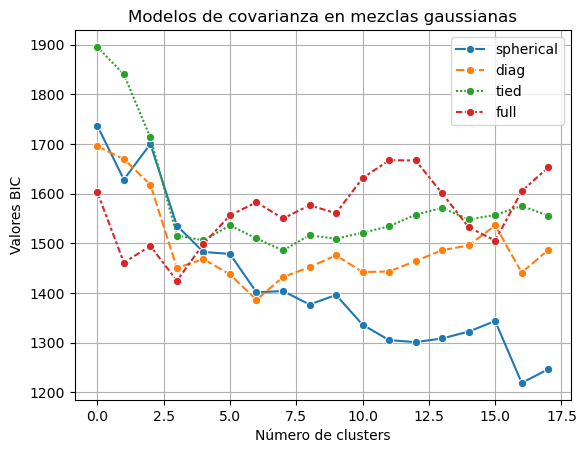

In [163]:
model_bics_df=pd.DataFrame(model_bics)
sns.lineplot(model_bics_df, markers='o')
plt.title('Modelos de covarianza en mezclas gaussianas')
plt.xlabel('Número de clusters')
plt.ylabel('Valores BIC')
plt.grid(True)

En el gráfico anterior se muestra que el valor mínimo de `BIC` ocurre con el modelo de covarianza `spherical`, sin embargo esto puede llevar a un sobre ajuste dado el número de clusters que se generan (al rededor de 12 clusters), en este caso elegiremos el modelo de covarianza que igual representa un mínimo: `diag`, con al rededor de 6 clusters.

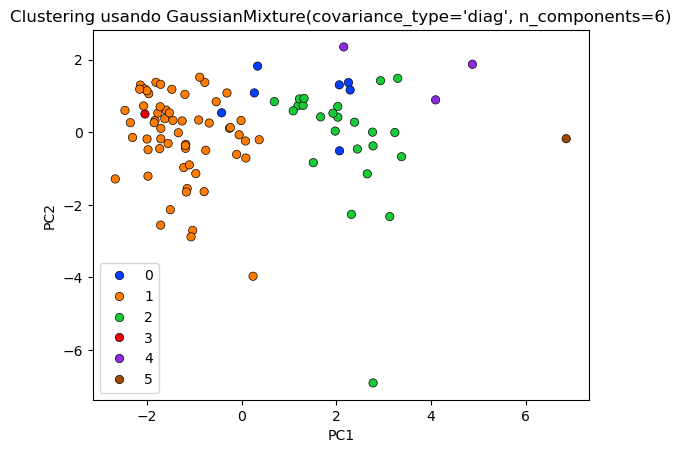

In [172]:
# Modelo con el número óptimo de clsuters
gmm_diag=GaussianMixture(n_components=6, covariance_type='diag')
gmm_diag.fit(X_pca)
# etiquetas
gmm_diag_labels=gmm_diag.predict(X_pca)

sns.scatterplot(
    x=X_pca.PC1, 
    y=X_pca.PC2, 
    hue=gmm_diag_labels, 
    palette='bright', 
    edgecolor='black')
plt.title(f'Clustering usando {gmm_diag}')
plt.show()

El modelo de covarianza anterior tampoco logra definir clusters de claidad, por lo que otra opción de mínimo es con el modelo `full` con al rededor de 3 clsuters.

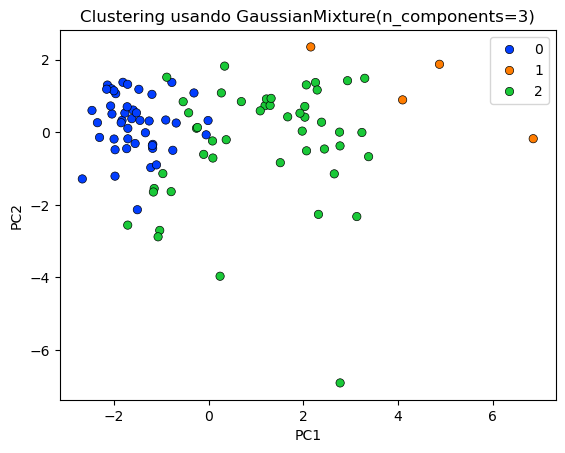

In [175]:
# Modelo con el número óptimo de clsuters
gmm_full=GaussianMixture(n_components=3, covariance_type='full')
gmm_full.fit(X_pca)
# etiquetas
gmm_full_labels=gmm_full.predict(X_pca)

sns.scatterplot(
    x=X_pca.PC1, 
    y=X_pca.PC2, 
    hue=gmm_full_labels, 
    palette='bright', 
    edgecolor='black')
plt.title(f'Clustering usando {gmm_full}')
plt.show()

Este modelo define de mejor manera 3 clusters.

### Pairplot

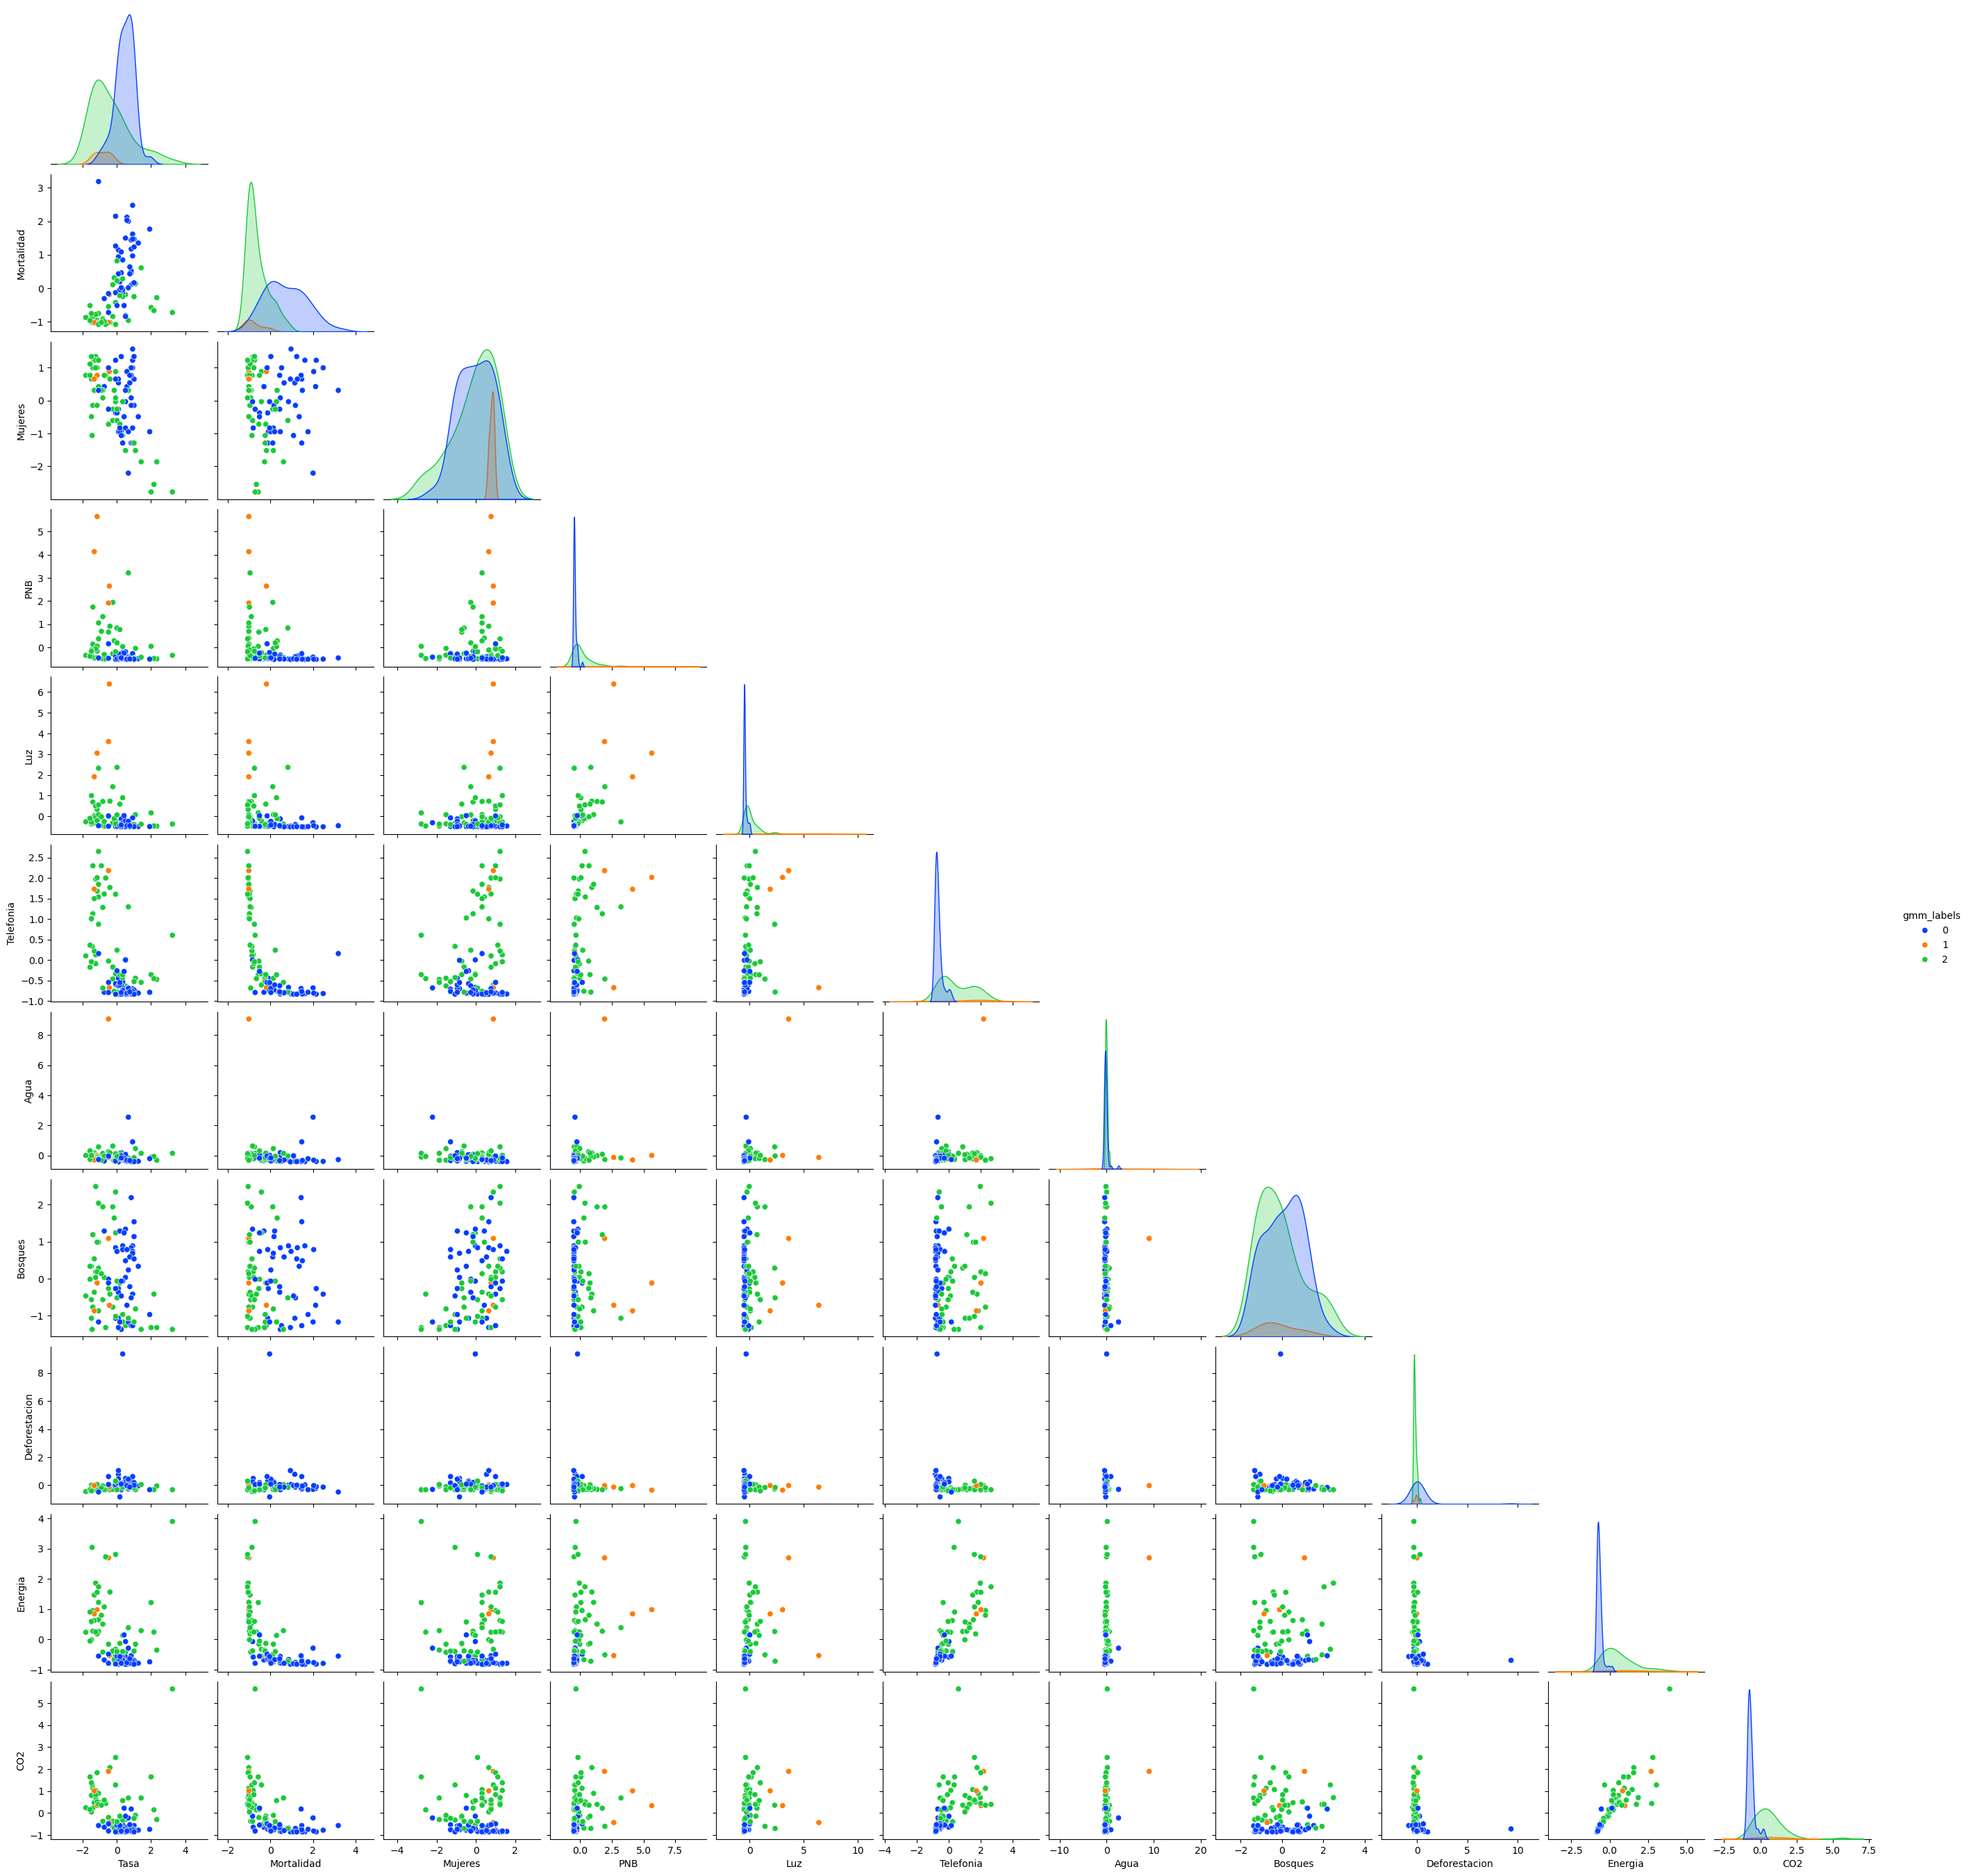

In [176]:
# hacemos un pairplot con los datos originales

# copiamos el dataframe con las etiquetas
X_gmm=X_df.copy()

# agregamos las etiquetas
X_gmm['gmm_labels']=gmm_full_labels

# graficamos 
sns.pairplot(
    data=X_gmm, 
    hue='gmm_labels',
    palette='bright',
    corner=True
)
plt.show()

## BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)

- Algoritmo de **clustering jerárquico incremental**.
- Diseñado para trabajar con **datasets grandes**.
- Utiliza una estructura llamada **CF Tree** (Clustering Feature Tree) para resumir los datos.

**Hiperparámetros clave**
- **`threshold`**: radio máximo permitido para un subcluster (el más importante).
- **`branching_factor`**: número máximo de hijos por nodo.
- **`n_clusters`**: número de clusters finales (opcional).

Antes de implementar el modelo estimaremos el valor de `threshold` usando la métrica de Silhouette.
- Es un número real positivo.
- No puede ser 0 (si fuera 0, ningún punto podría agruparse).
- Mientras más pequeño, más subclusters se generan.
- Mientras más grande, menos subclusters (puede llegar al extremo de que todo quede en un solo cluster).

Primero tenemos que encontrar el rango de `threshold` donde se forman los clusters.

threhold= 0.1 hay 96 clusters
threhold= 0.25263157894736843 hay 84 clusters
threhold= 0.4052631578947369 hay 70 clusters
threhold= 0.5578947368421052 hay 51 clusters
threhold= 0.7105263157894737 hay 40 clusters
threhold= 0.8631578947368421 hay 33 clusters
threhold= 1.0157894736842106 hay 29 clusters
threhold= 1.168421052631579 hay 22 clusters
threhold= 1.3210526315789475 hay 17 clusters
threhold= 1.473684210526316 hay 15 clusters
threhold= 1.6263157894736844 hay 12 clusters
threhold= 1.7789473684210528 hay 11 clusters
threhold= 1.931578947368421 hay 7 clusters
threhold= 2.0842105263157893 hay 7 clusters
threhold= 2.236842105263158 hay 6 clusters
threhold= 2.3894736842105266 hay 6 clusters
threhold= 2.542105263157895 hay 6 clusters
threhold= 2.694736842105263 hay 5 clusters
threhold= 2.8473684210526318 hay 4 clusters
threhold= 3.0 hay 4 clusters


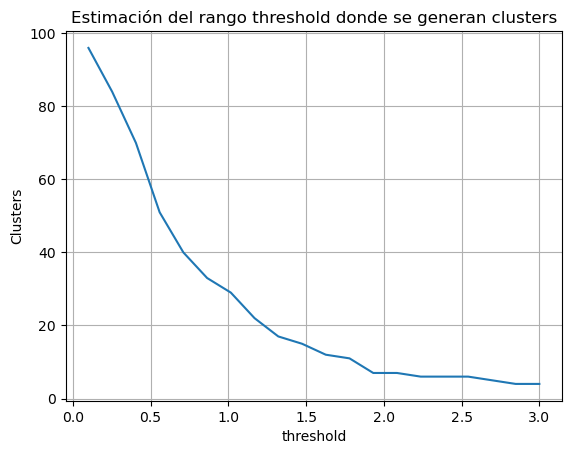

In [187]:
# valores de prueba
th_values=np.linspace(0.1, 3.0, 20)
# donde se guardarán las puntuaciones
clusters=[]

for i in th_values:
    birch=Birch(threshold=i, n_clusters=None)
    birch_labels=birch.fit_predict(X_pca)
    n_clusters=len(set(birch_labels))
    clusters.append(n_clusters)
    print(f'threhold= {i} hay {n_clusters} clusters')


# graficamos
sns.lineplot(
    x=th_values, 
    y=clusters
)
plt.title('Estimación del rango threshold donde se generan clusters')
plt.xlabel('threshold')
plt.ylabel('Clusters')
plt.grid(True)
plt.show()    


En este caso un valor mínimo de `threshold` sobreajusta los datos de tal manera que para 0.1 se genera un único cluster. Para medir la calidad de los clusters generados hacemos un estudio de la métrica de Silhouette evitando el valor donde se genera un único cluster.

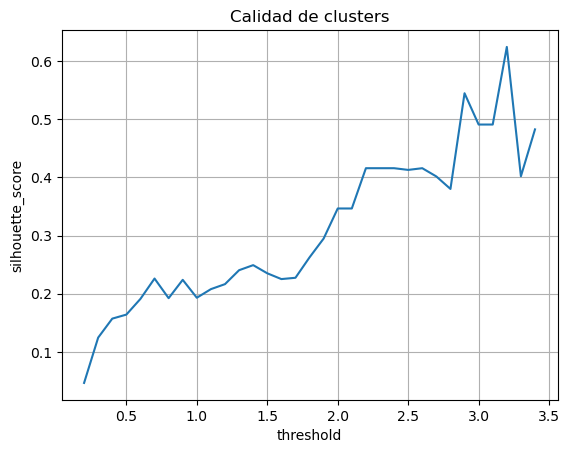

In [194]:
# valores de prueba
th_values=np.arange(0.2, 3.5, 0.1)
# donde se guardarán las puntuaciones
sh_scores=[]

for i in th_values:
    birch=Birch(threshold=i, n_clusters=None)
    birch_labels=birch.fit_predict(X_pca)
    sh=silhouette_score(X_pca, birch_labels)
    sh_scores.append(sh)


# graficamos
sns.lineplot(
    x=th_values, 
    y=sh_scores
)
plt.title('Calidad de clusters')
plt.xlabel('threshold')
plt.ylabel('silhouette_score')
plt.grid(True)
plt.show()

De acuerdo a `silhouette_score` tenemos la mejor calidad de clusters en aproximadamente 2.8 con un aproximado de 4 clusters para el primer pico en la métrica de Silhouette.

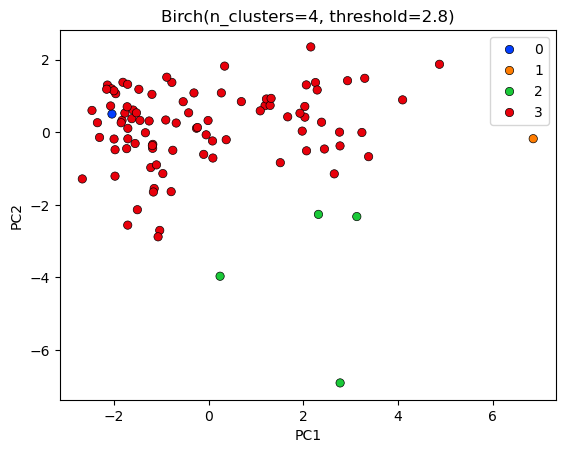

In [205]:
# modelo con los mejores hiperparámetros
birch=Birch(threshold=2.8, n_clusters=4)
birch_labels=birch.fit_predict(X_pca)

# graficamos 
sns.scatterplot(
    x=X_pca['PC1'],
    y=X_pca['PC2'],
    hue=birch_labels,
    palette='bright',
    edgecolor='black'
)
plt.title(birch)
plt.show()

In [209]:
# agregamos las etiquetas a los datos originales
X_birch=X_df.copy()
X_birch['birch_labels']=birch_labels

### Pairplot

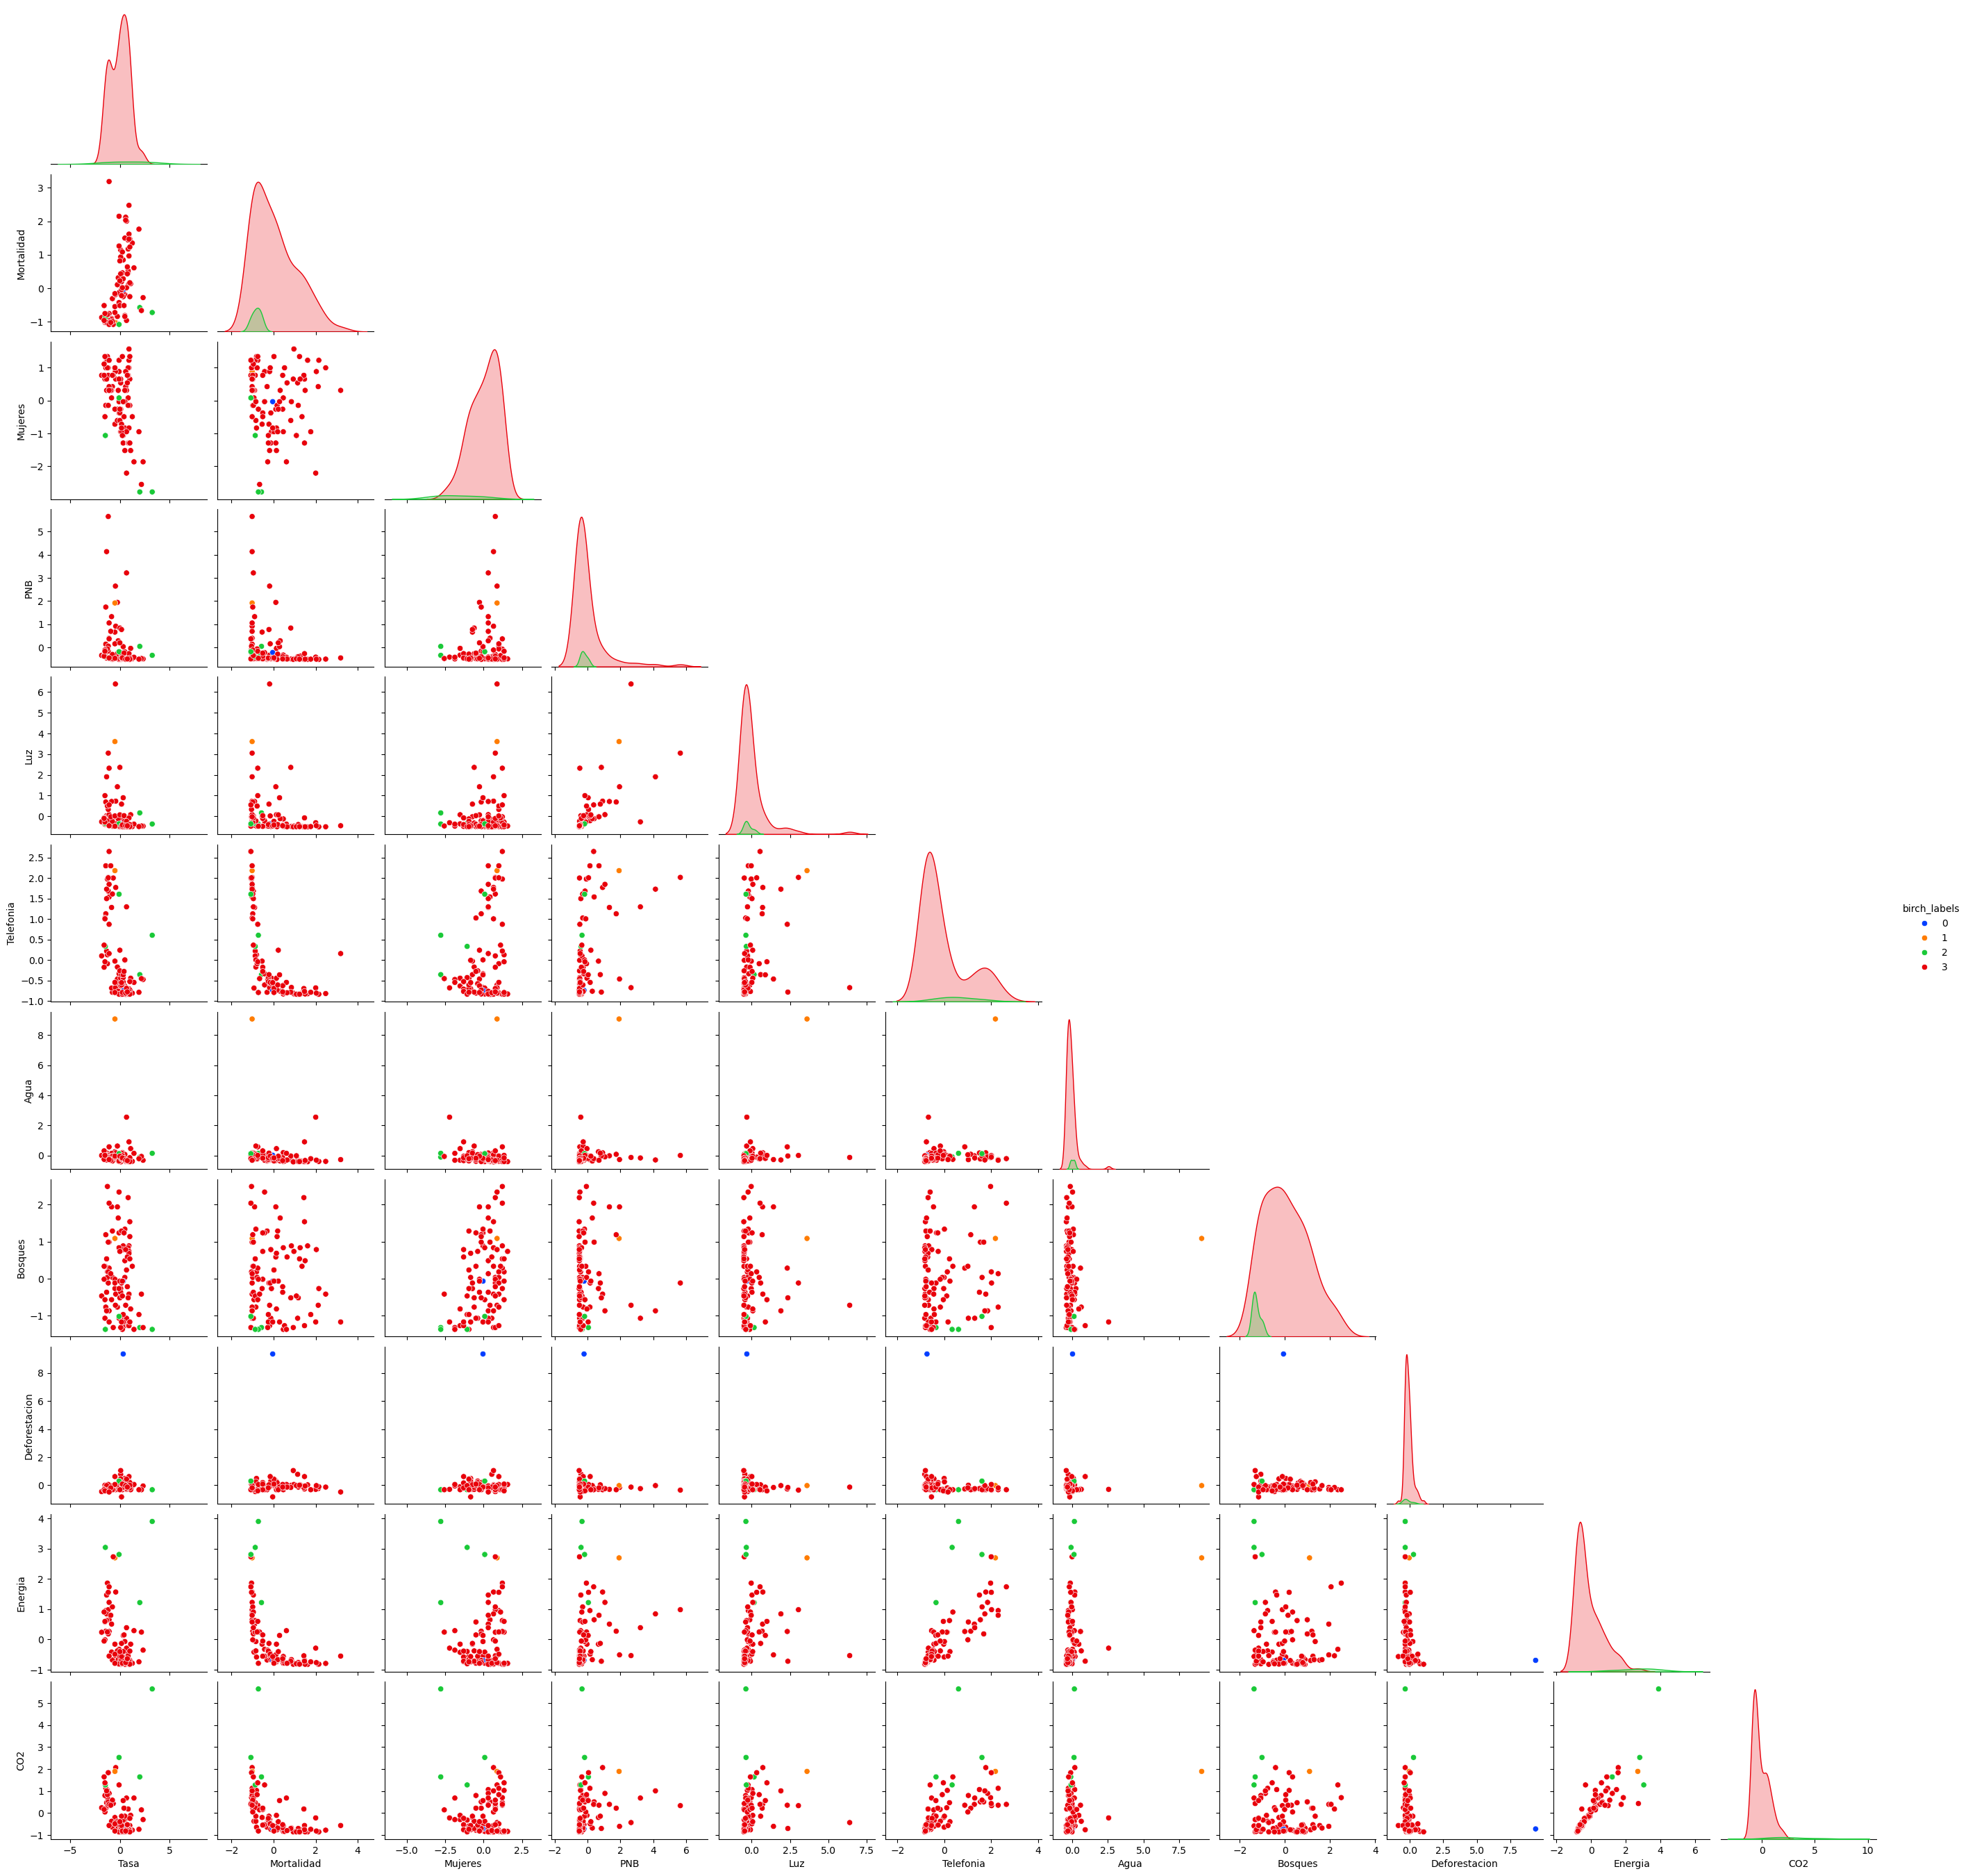

In [210]:
# graficamos un pairplot
sns.pairplot(
    data=X_birch, 
    hue='birch_labels',
    corner=True,
    palette='bright'
)
plt.show()

# Conclusiones
Se probaron 6 modelos de clustering para clasificar los datos usando PCA, esto con dos objetivos:
- Reducir la dimensionalidad del conjunto de datos conservando la máxima varianza explicada.
- Reducir el impacto de valores atípicos y  el ruido.

Las componentes PCA obtenidas representan casi el 88% de la varianza explciada total, lo que parece razonable para la dimensión original de los daots (11 predictores).

Las dos primeras componentes de PCA  (PC1 y PC2) contienen la mayor parte de la varianza explicada, por lo que los gráficos de cada clsutering se llevaron a cabo tomando en cuenta dichos predictores.

## Elección del mejor modelo
Como hemos mencionado anteriormente, se probaron 6 algoritmos de clustering con las siguientes observaciones generales:
- `K-means`: identifica de una manera aceptable 5 clusters, dso principales etiquetados con 0 y 1, luego clasifica los 3 restantes como valores atípicos, cada uno. El gráfico `pairplot` muestra una separación relativamente buiena de lso datos procesados.
- `Agglomerative`: de una amnera similar a `K-means`, logra visualizar clusters separados, sin embargo, aquí se han obtenido 4 clusters, donde se pueden identificar correctamente los valores atípicos.
- `DBSCAN`: fue el de menor desempeño pues sobre ajustó los datos de tal manera que logró identificar dos clusters, el primero donde se encuentra la mayor densidad de los datos, y otro donde se muestran los valores atípicos, esto hace ver el poder de este algoritmo par aidentificar *outliers*.
- `Affinity`: a pesar de implementar técnicas para la obtención de los mejores hiperparámetros, el modelo identificaó 13 clusters, sin embargo, esta cantidad de clusters sobre ajusta el modelo y no es capaz de separar nítidamente los grupos.
- `GaussianMixture`: de los modelos vistos anetriormente, este es el que pudo clasificar de fomra exitosa 3 clsuters visiblemente separados, si bien existe aún un a mezcla de puntos, es notable diferencia respecto a los otros modelos, además de que los mejores hiperparámetros fueron encontrados iterando distintos modelos de covarianza, siendo `full`el elegido.
- `BIRCH`: de los modelos anteriores el más robusto para bases de datos muy grandes, se lograron resultados similares a los obtenidos con mezclas gaussianas, generadno 4 clusters relativamente bien definidos, destaca la identificación y clasificación de los valores atípicos. Este modelo fue probado para distintos valores de `threshold` para obtener el número óptimo de clusters y evitar el sobre ajuste.
---
En resumen, los modelos que clasificación de mejor forma los datos fueron `GaussianMixture`y `BIRCH`, por lo que se usarán para identificar los países en los datos clasificados.

## Análisis por grupos
Tomando los mejores modelos de clsutering, haremos un análisis de los grupos generados# .

In [251]:
# Agregamos la columna de paisesa

# GaussianMixutres
X_gmm['paises']=paises

# BIRCH
X_birch['paises']=paises

In [288]:
print('GaussianMixture tiene los grupos',X_gmm['gmm_labels'].value_counts())

GaussianMixture tiene los grupos gmm_labels
2    47
0    45
1     4
Name: count, dtype: int64


In [289]:
print('BIRCH tiene los grupos',X_birch['birch_labels'].value_counts())

BIRCH tiene los grupos birch_labels
3    90
2     4
1     1
0     1
Name: count, dtype: int64


### GaussianMixture

In [272]:
# obtenemos los promedios por cluster
describe_clusters_gmm=X_gmm.groupby('gmm_labels')[X.columns].mean()
describe_clusters_gmm

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
gmm_labels,,,,,,,,,,,
0,0.454551,0.721747,-0.006763,-0.433467,-0.424296,-0.665025,-0.152604,0.102630,0.243796,-0.670742,-0.667511
1,-0.852294,-0.812274,0.798419,3.584693,3.739204,1.312398,2.166888,-0.154782,-0.136269,0.995952,0.701842
2,-0.362673,-0.621905,-0.061475,0.109941,0.088010,0.525033,-0.038306,-0.085090,-0.221824,0.557438,0.579376


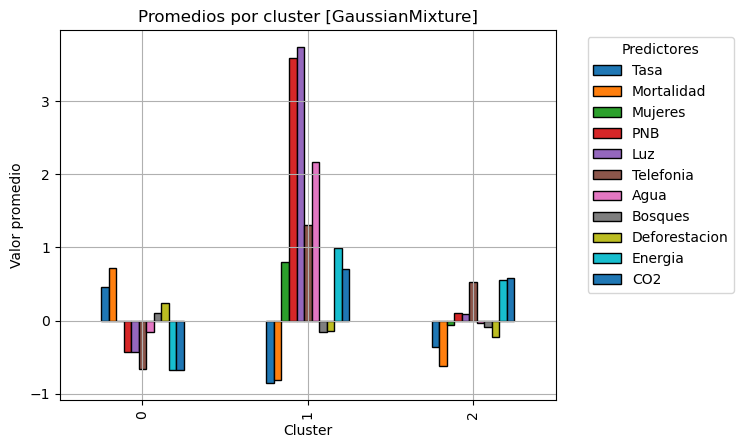

In [286]:
# grafica de promedios
describe_clusters_gmm.plot(kind='bar', edgecolor='black')
plt.title("Promedios por cluster [GaussianMixture]")
plt.xlabel("Cluster")
plt.ylabel("Valor promedio")
plt.grid(True)
plt.legend(title="Predictores", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [287]:
X_gmm[['gmm_labels','paises']].sort_values('gmm_labels')

,gmm_labels,paises
0,0,Albania
1,0,Angola
7,0,Bangladesh
9,0,Benin
11,0,Bolivia
...,...,...
82,2,Suecia
84,2,Sudáfrica
83,2,Suiza
88,2,Turquia


En el gráfico de arriba se muestran los promedios para cada cluster por predictor. A continuación se muestran algunas observaciones:
- **En el grupo 0** muestra en su mayoría valores promedio negativos, lo que indica que los predictores están por debajo de la media internacional, por ejemplo: energía, PNB, telefonía, CO2, luz y agua. Mientras que los predictores que tienen un valor superior a la media internacional son: mortalidad y natalidad, siendo mortalidad la predominante. Esto parece indicar un grupo de países en desarrollo, donde las condiciones sociales no permiten que los predictores negativos se eleven sobre la media, y es claro cuando nos encontramos en este grupo a la mayoría de países africanos y algunos países de américa latina como Ecuador, Uruguay y Venezuela.
- **En el grupo 1** existen predictores considerablemente elevados sobre la media, por  ejemplo: PNB, luz, agua, telefonía, mujeres, energía y CO2. Esto es representa claramente países desarrollados donde se concentra mayor riqueza, aquellos países donde las emisiones de CO2 y donde la gneración de energía son superiores a la media internacional, también existen las condiciones sociales en las que hay más mujeres activas en la población. 
  
  De igual manera, existen predictores negativos en los que resaltan la tasa de natalidad y mortalidad, siendo natalidad la predominante. Que estos promedios estén tan alejados de la media internacional indica que dichos países se encuentran desacelerando ambas tasas, la mortalidad por su puesto es consecuencia de países desarrollados en los que el acceso a la salud es sobresalientemente mejor, en cambio el descenso de la nataidad puede deberse en parte factores sociales en los que se prioriza planes de vida que no incluyen la maternidad ni paternidad.
  
  En este grupo solo encontramos cuatro países: Francia, Reino Unido, China y Canadá.

- **En el grupo 2** encontramos a los países en vías de desarrollo, donde las tasas de mortalidad y natalidad más alejadas de la media global. Que la infraestructura telefónica esté por encima del promedio indica que dichos países tienen una mejor infraestructura de trelecomunicaciones, al igual que la gneración de energía y las emisiones de CO2. Es notable que en dicho grupo, tenga una baja tasa de mujeres activa en comparación a los países del grupo 0 donde es casi inexistente. 
  En este cluster nos encotramos con la (casi) otra mitad de los paises, por ejemplo la gran mayoría de Europa, parte de medio oriente (Emiratos Árabes, Siria , Israel, etc.), este grupo también incluye a la gran mayoría de los países asiáticos como Japón, Filipinas, India, Corea del Norte, Corea del Sur. Sudafrica es el único país africano que entra en esta categoría, esto indica que tiene niveles demográficos superiores respecto a sus pares regionales.

  En América Latina nos encontramos a México, Brasil, Argentina y Cuba; países destacados del contienente donde las condiciones sociales, econoómicas son más avanzadas que los otros países de la region.

#### México
Nos encontramos en el segundo grupo, donde las tasas de mortalidad y natalidad son inferiores al promedio global, en un país en vías de desarrollo, donde el producto interno bruto es ligeramente superior a la media. La clasificación dentro de este grupo no está alejada de la realidad, pues no tiene los indicadores del grupo 0, ni es un país económicamente rico para pocisionarse dentro del grupo 1.

### BIRCH

In [278]:
# obtenemos los promedios por cluster
describe_clusters_birch=X_birch.groupby('birch_labels')[X.columns].mean()
describe_clusters_birch


,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
birch_labels,,,,,,,,,,,
0,0.340069,-0.041972,-0.032223,-0.215099,-0.314287,-0.739226,0.021338,-0.066933,9.353442,-0.690624,-0.722696
1,-0.490846,-1.019663,0.884347,1.917300,3.608993,2.179209,9.076604,1.087657,-0.029041,2.693301,1.895373
2,0.932096,-0.812274,-1.636221,-0.217587,-0.231520,0.546886,0.022802,-1.271722,-0.169778,2.738866,2.776084
3,-0.039751,0.047897,0.063253,-0.009243,-0.026318,-0.040306,-0.102102,0.045180,-0.096059,-0.143979,-0.136411


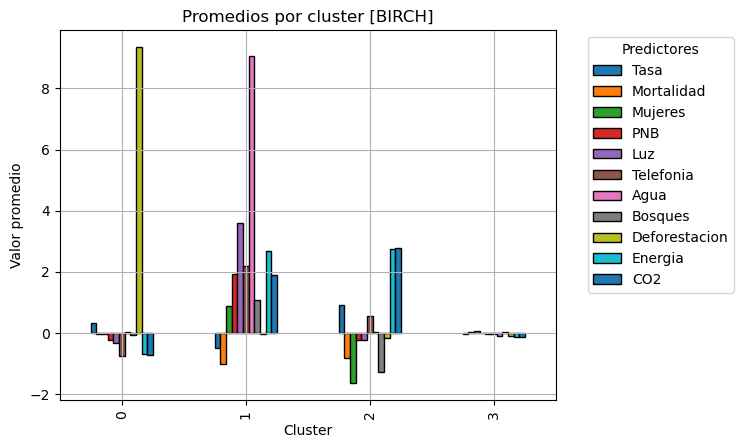

In [290]:
# grafica de promedios
describe_clusters_birch.plot(kind='bar', edgecolor='black')
plt.title("Promedios por cluster [BIRCH]")
plt.xlabel("Cluster")
plt.ylabel("Valor promedio")
plt.grid(True)
plt.legend(title="Predictores", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [291]:
X_birch[['birch_labels','paises']].sort_values('birch_labels')

,birch_labels,paises
34,0,Filipinas
15,1,Canadá
30,2,E. Arabes Uni
2,2,Arabia Saudi
54,2,Kuwait
...,...,...
91,3,Venezuela
92,3,Vietnam
93,3,Yemen
94,3,Zambia


Visualizando los promedios, este modelo de clasificación no captura la realidad mundial, pues genera clusters casi individuales, si bien, sirve para identificar outliers como Filipinas con los niveles de deforestación más altos del planeta y canadá como uno de los países que más cosumen agua en el planeta. Estos matices no fueron capturados por mezclas gaussianas, sin embargo complementan el análsisi aportando información refinada por país.

🌌